# Load ERA5-Land Data

In [1]:
# auto reload modified modules
%load_ext autoreload
%autoreload 2
import sys
WORK_DIR = "/home/research/jenzheng/documents/kai/research/eta"
sys.path.append(WORK_DIR)

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from plot_utils import plot_setting, plot_nfields 
from utils import *
import torch
import torch.nn as nn
from tqdm import tqdm
plot_setting()

# Load the cropped data
file_path = WORK_DIR + '/data/ERA5/era5land_USA_SouthEast_1999-2023_dailymax.nc'
ds = xr.open_dataset(file_path, engine='netcdf4')

# Extract the 'tp' variable (Total Precipitation)
tp = ds['tp']

# Convert to a NumPy array and multiply by 1000 (meter to millimeter)
tp_numpy = tp.values * 1000
# 
# Check if there are any NaN values
has_nan = np.isnan(tp_numpy).any()
# print(f"Contains NaN values: {has_nan}")

# Set device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Downsample Data

In [2]:
# Downsampling by a factor of 2 for each spatial dimension
ds_fact = 10
tp_ds_numpy = tp_numpy[:, ::ds_fact, ::ds_fact]  # (9050, 40, 80)

In [3]:
def plot_contour(data_snapshot, title_date=None, latitudes=tp.latitude.values, longitudes=tp.longitude.values):
    """
    Function to create a contour plot for a single snapshot of precipitation data.
    
    Parameters:
    data_snapshot (numpy array): 2D numpy array of precipitation data at a specific time.
    latitudes (numpy array): 1D array of latitude values.
    longitudes (numpy array): 1D array of longitude values.
    title_date (str): Date string for the title of the plot, e.g., '1999-06-15'.
    """
    # Set up the map for plotting
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()}, dpi=300)

    # Add features to the map (state borders, coastlines)
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1)

    # Plot the precipitation data
    contour = ax.contourf(longitudes, latitudes, data_snapshot, cmap='Blues', transform=ccrs.PlateCarree())

    # Adjust color bar size and position
    cbar = plt.colorbar(contour, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
    
    # Set the extent to match the spatial range
    ax.set_extent([longitudes.min(), longitudes.max(), latitudes.min(), latitudes.max()], crs=ccrs.PlateCarree())

    # Add title (date without hour information)
    if title_date:
        plt.title(f"Peak Precipitation (mm) on {title_date}", fontsize=16)
    else:
        plt.title(f"Peak Precipitation (mm)", fontsize=16)

    # Apply tight layout
    plt.tight_layout()

    # Show the plot
    plt.show()


def plot_nfields(*snapshots, title_date=None, latitudes=tp.latitude.values, longitudes=tp.longitude.values, cmap="jet", ds_fact=1):
    """
    Plots multiple snapshots of climate field data in separate subplots, stacked vertically.
    All snapshots share the same colorbar and color scale.

    Parameters:
    *snapshots (numpy arrays): Variable number of 2D arrays of data for the snapshots.
    latitudes (numpy array): 1D array of latitude values.
    longitudes (numpy array): 1D array of longitude values.
    title_date (str): Date string for the title of the plot, e.g., '1999-06-15'.
    """
    # Check lat/lon
    if latitudes is None or longitudes is None:
        raise ValueError("Latitudes and longitudes must be provided.")
    
    if len(snapshots) == 0:
        raise ValueError("At least one snapshot must be provided.")

    # Determine global min and max from all snapshots for consistent coloring
    combined_min = np.min([snapshot.min() for snapshot in snapshots])
    combined_max = np.max([snapshot.max() for snapshot in snapshots])

    # Avoid collapsed color scale
    if combined_min == combined_max:
        combined_max += 1e-3  # Add a small epsilon if values are uniform

    # Create figure and axes (n rows, 1 column)
    n_fields = len(snapshots)
    fig, axes = plt.subplots(nrows=n_fields, ncols=1, figsize=(10, 4 * n_fields),
                             subplot_kw={'projection': ccrs.PlateCarree()},
                             dpi=400)

    # If only one subplot, ensure axes is a list for consistency
    if n_fields == 1:
        axes = [axes]

    # Add features to each axis and plot data
    for i, (ax, snapshot) in enumerate(zip(axes, snapshots)):
        ax.add_feature(cfeature.STATES, edgecolor='#d3d3d3', linewidth=1)
        ax.add_feature(cfeature.COASTLINE, edgecolor='#d3d3d3', linewidth=1)

        # Plot the snapshot
        if ds_fact > 1:
            ds_long = longitudes[::ds_fact]
            ds_lat = latitudes[::ds_fact]
            if i!=0:
                img = ax.pcolormesh(longitudes, latitudes, snapshot, cmap=cmap, 
        #                             norm=PowerNorm(gamma=2, vmin=combined_min, vmax=combined_max),
                                    vmin=combined_min, vmax=combined_max,
                                    transform=ccrs.PlateCarree(), shading='auto')
            else:
                img = ax.pcolormesh(ds_long, ds_lat, snapshot, cmap=cmap, 
        #                             norm=PowerNorm(gamma=2, vmin=combined_min, vmax=combined_max),
                                    vmin=combined_min, vmax=combined_max,
                                    transform=ccrs.PlateCarree(), shading='auto')
        else:
            img = ax.pcolormesh(longitudes, latitudes, snapshot, cmap=cmap, 
    #                             norm=PowerNorm(gamma=2, vmin=combined_min, vmax=combined_max),
                                vmin=combined_min, vmax=combined_max,
                                transform=ccrs.PlateCarree(), shading='auto')

        # Set extent
        ax.set_extent([longitudes.min(), longitudes.max(), latitudes.min(), latitudes.max()], crs=ccrs.PlateCarree())

        # Title for each subplot
#         ax.set_title(f"Field (Snapshot {i+1})", fontsize=14)

    # Create a single colorbar
    if title_date:
        axes[0].set_title(f"Peak Precipitation (mm) on {title_date}", fontsize=18)
    plt.tight_layout()
    cbar = plt.colorbar(img, ax=axes, orientation='vertical', fraction=0.04 if n_fields==1 else 0.01 * n_fields, pad=0.02)
    tick_pos = np.linspace(combined_min, combined_max, 6)
    cbar.set_ticks(tick_pos)
    cbar.ax.tick_params(labelsize=14)
    plt.show()


# KDE

In [5]:
from kde import get_data_pdf

# Sort Original Dataset Max

In [6]:
# Assuming tp_numpy has shape (9050, 80, 160)
max_values_original = np.max(tp_numpy, axis=(1, 2))
# train_max_values = np.max(tp_numpy[:train_size], axis=(1, 2))

# max_values_original will have shape (9050,)
print(max_values_original.shape)

# Sort max_values and get the indices that would sort the array
sorted_indices_original = np.argsort(max_values_original)
print(0 in sorted_indices_original)

# Use the sorted_indices to get the sorted max_values
sorted_max_values_original = max_values_original[sorted_indices_original]

(9050,)
True


# Take a Look At Training V.S. Full-Data PDFs

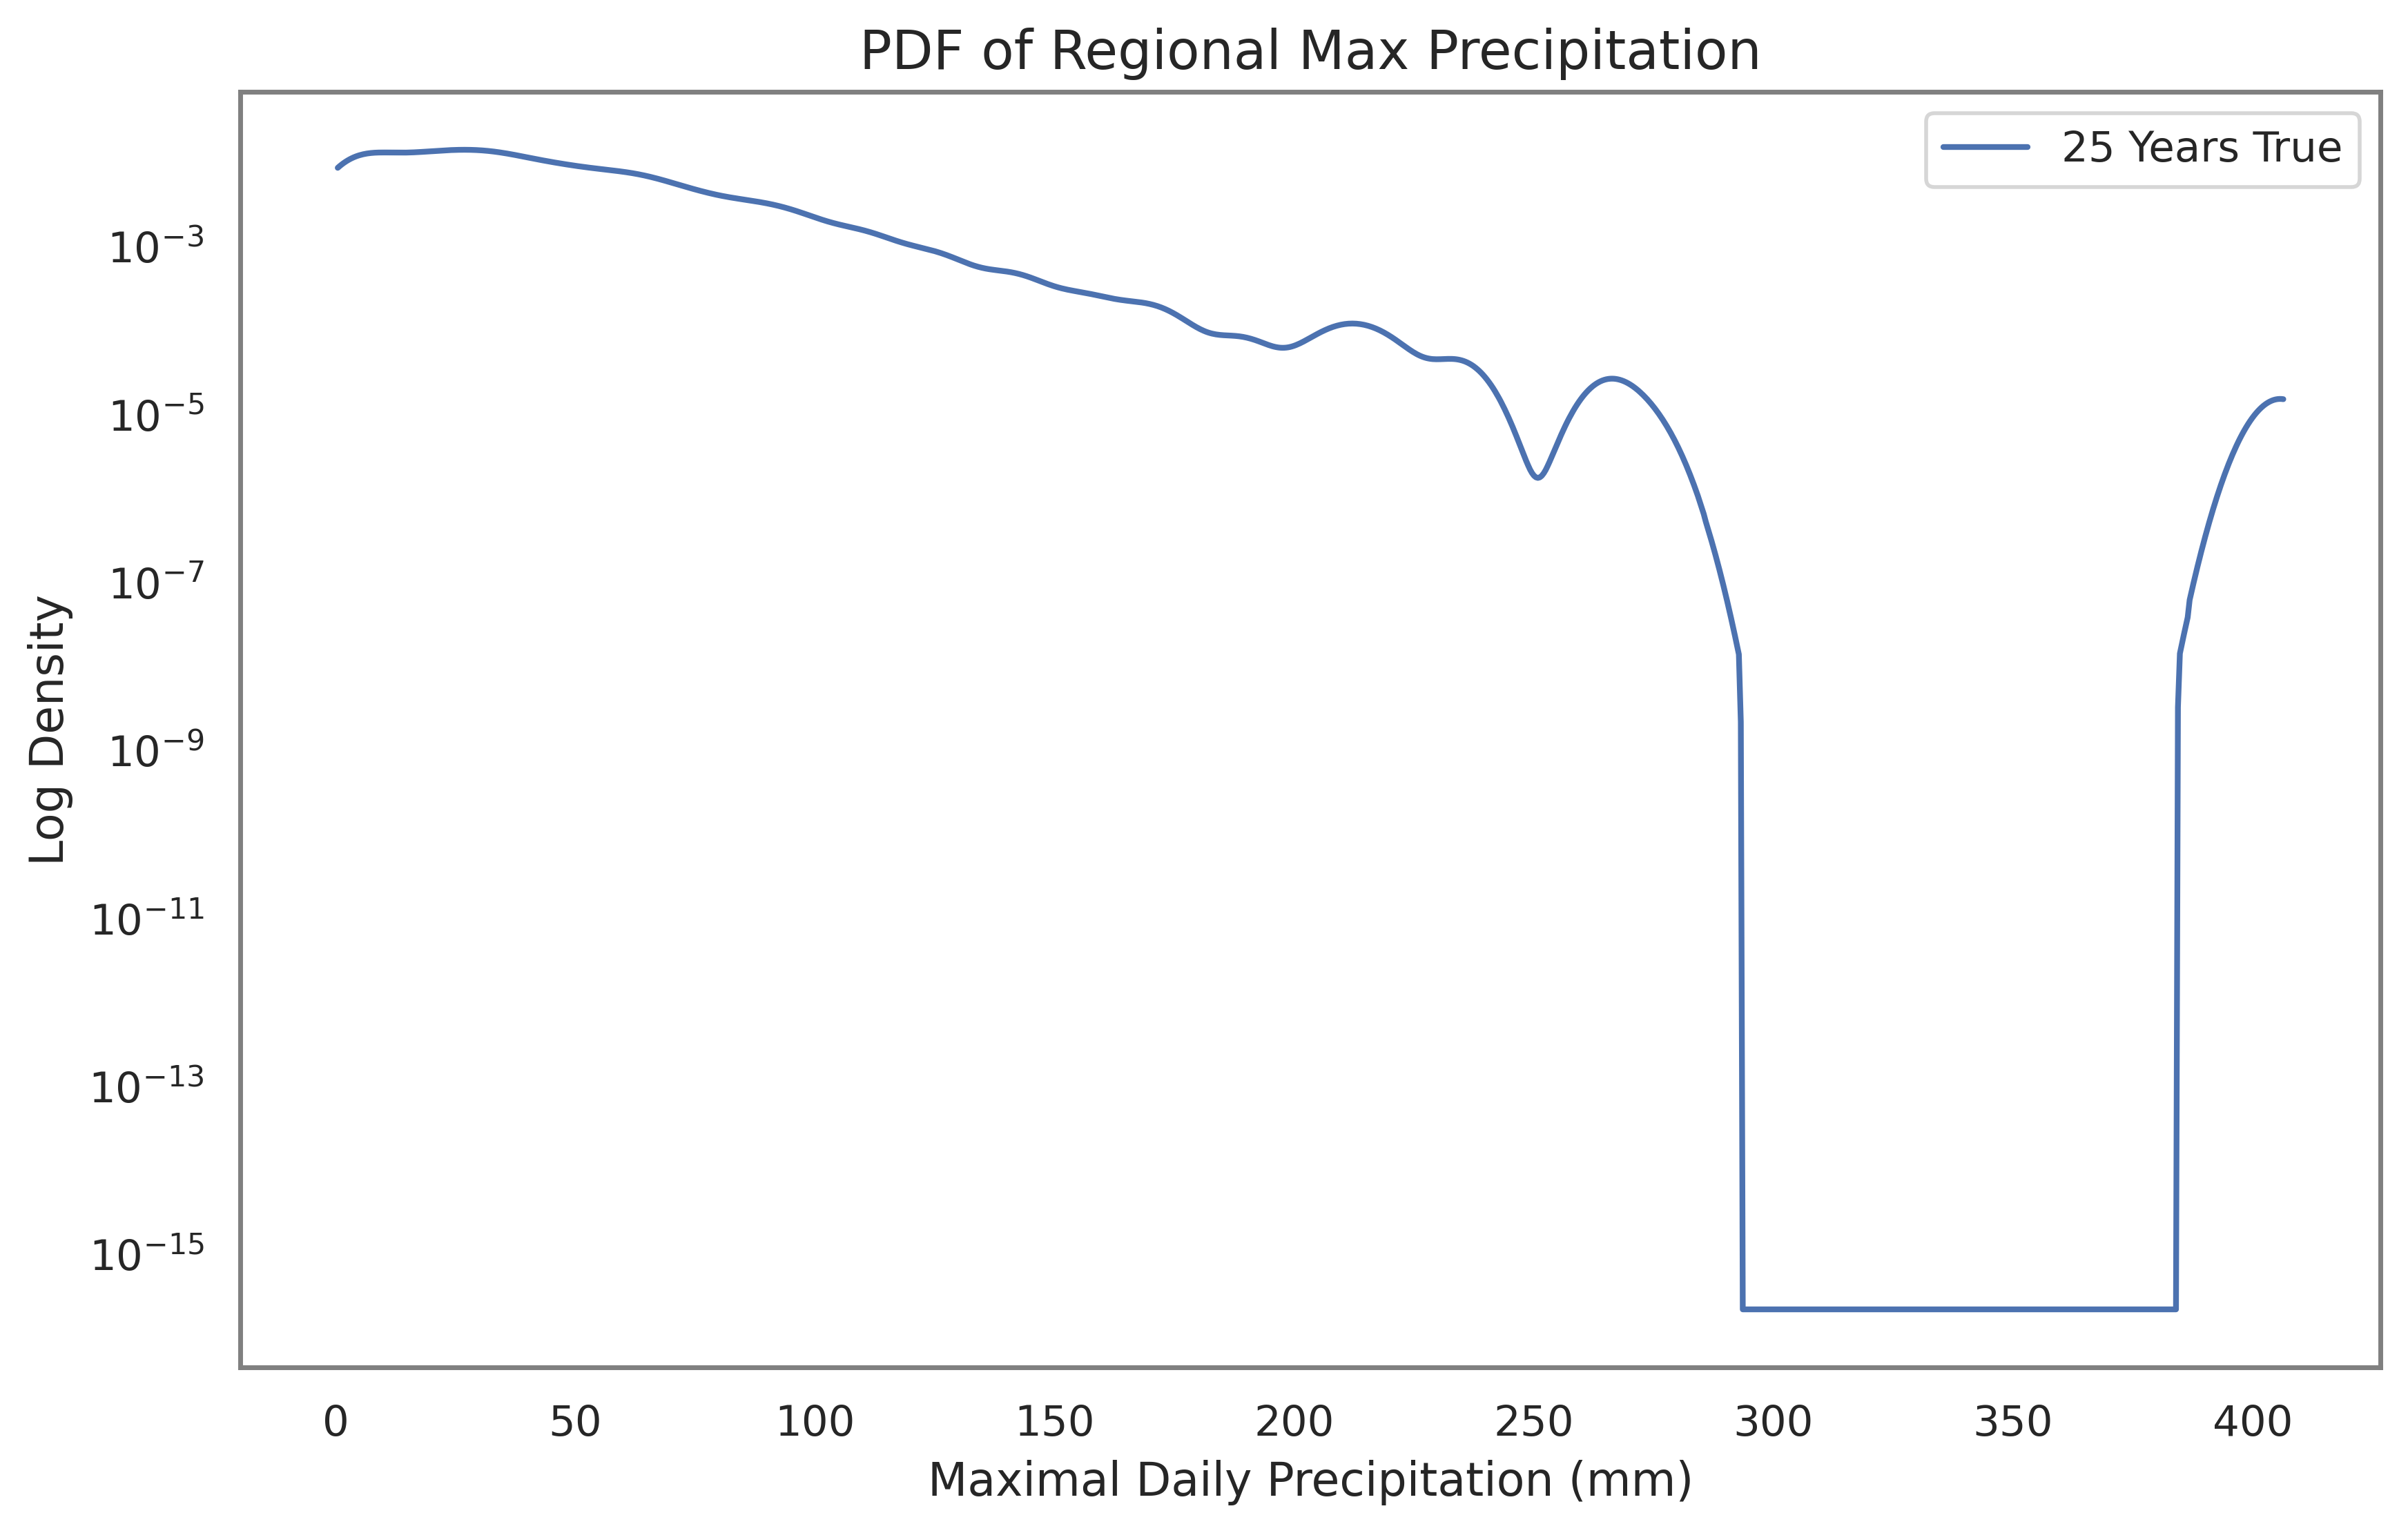

In [7]:
y_eval_tp, py_tp, _ = get_data_pdf(data=torch.tensor(sorted_max_values_original), data_all=torch.tensor(sorted_max_values_original))
# y_eval_tp_train, py_tp_train, _ = get_data_pdf(data=torch.tensor(train_max_values), data_all=torch.tensor(train_max_values))

# Plotting the two KDEs for comparison
plt.figure(figsize=(10, 6), dpi=400)

# Plot the KDE for the original data
plt.plot(y_eval_tp, py_tp, label="25 Years True")
# plt.plot(y_eval_tp_train, py_tp_train, label="5 Years True")

# Add plot labels and title
plt.xlabel("Maximal Daily Precipitation (mm)")
plt.ylabel("Log Density")
plt.title("PDF of Regional Max Precipitation", fontsize=14)
plt.yscale('log')
plt.legend()

# The Tail is Pathological. Trim the 25 Years Data

In [8]:
trim_tail_thresh = 240
num_trim_days = len(sorted_max_values_original[sorted_max_values_original > trim_tail_thresh])
trim_days = sorted_indices_original[-num_trim_days:]
# kept_days = sorted_indices[:-num_trim_days]
sorted_max_values_trim = sorted_max_values_original[:-num_trim_days]
sorted_indices_trim = sorted_indices_original[:-num_trim_days]
print("Trimmed Days: ", trim_days)
print("Trimmed Values: ", sorted_max_values_original[-num_trim_days:])

Trimmed Days:  [3533 4611 4610 3534 6353 6354]
Trimmed Values:  [264.42355 265.57224 265.57224 272.9087  404.68246 406.81866]


In [9]:
kept_days = np.delete(np.arange(len(tp_numpy)), trim_days)
tp_trim_numpy = tp_numpy[kept_days]
tp_trim_ds_numpy = tp_ds_numpy[kept_days]
tp_trim_tensor = torch.tensor(tp_trim_numpy)
tp_trim_ds_tensor = torch.tensor(tp_trim_ds_numpy)
print(tp_trim_ds_tensor.shape)
print(tp_trim_tensor.shape)

torch.Size([9044, 8, 16])
torch.Size([9044, 80, 160])


# Trimmed Full Dataset PDF

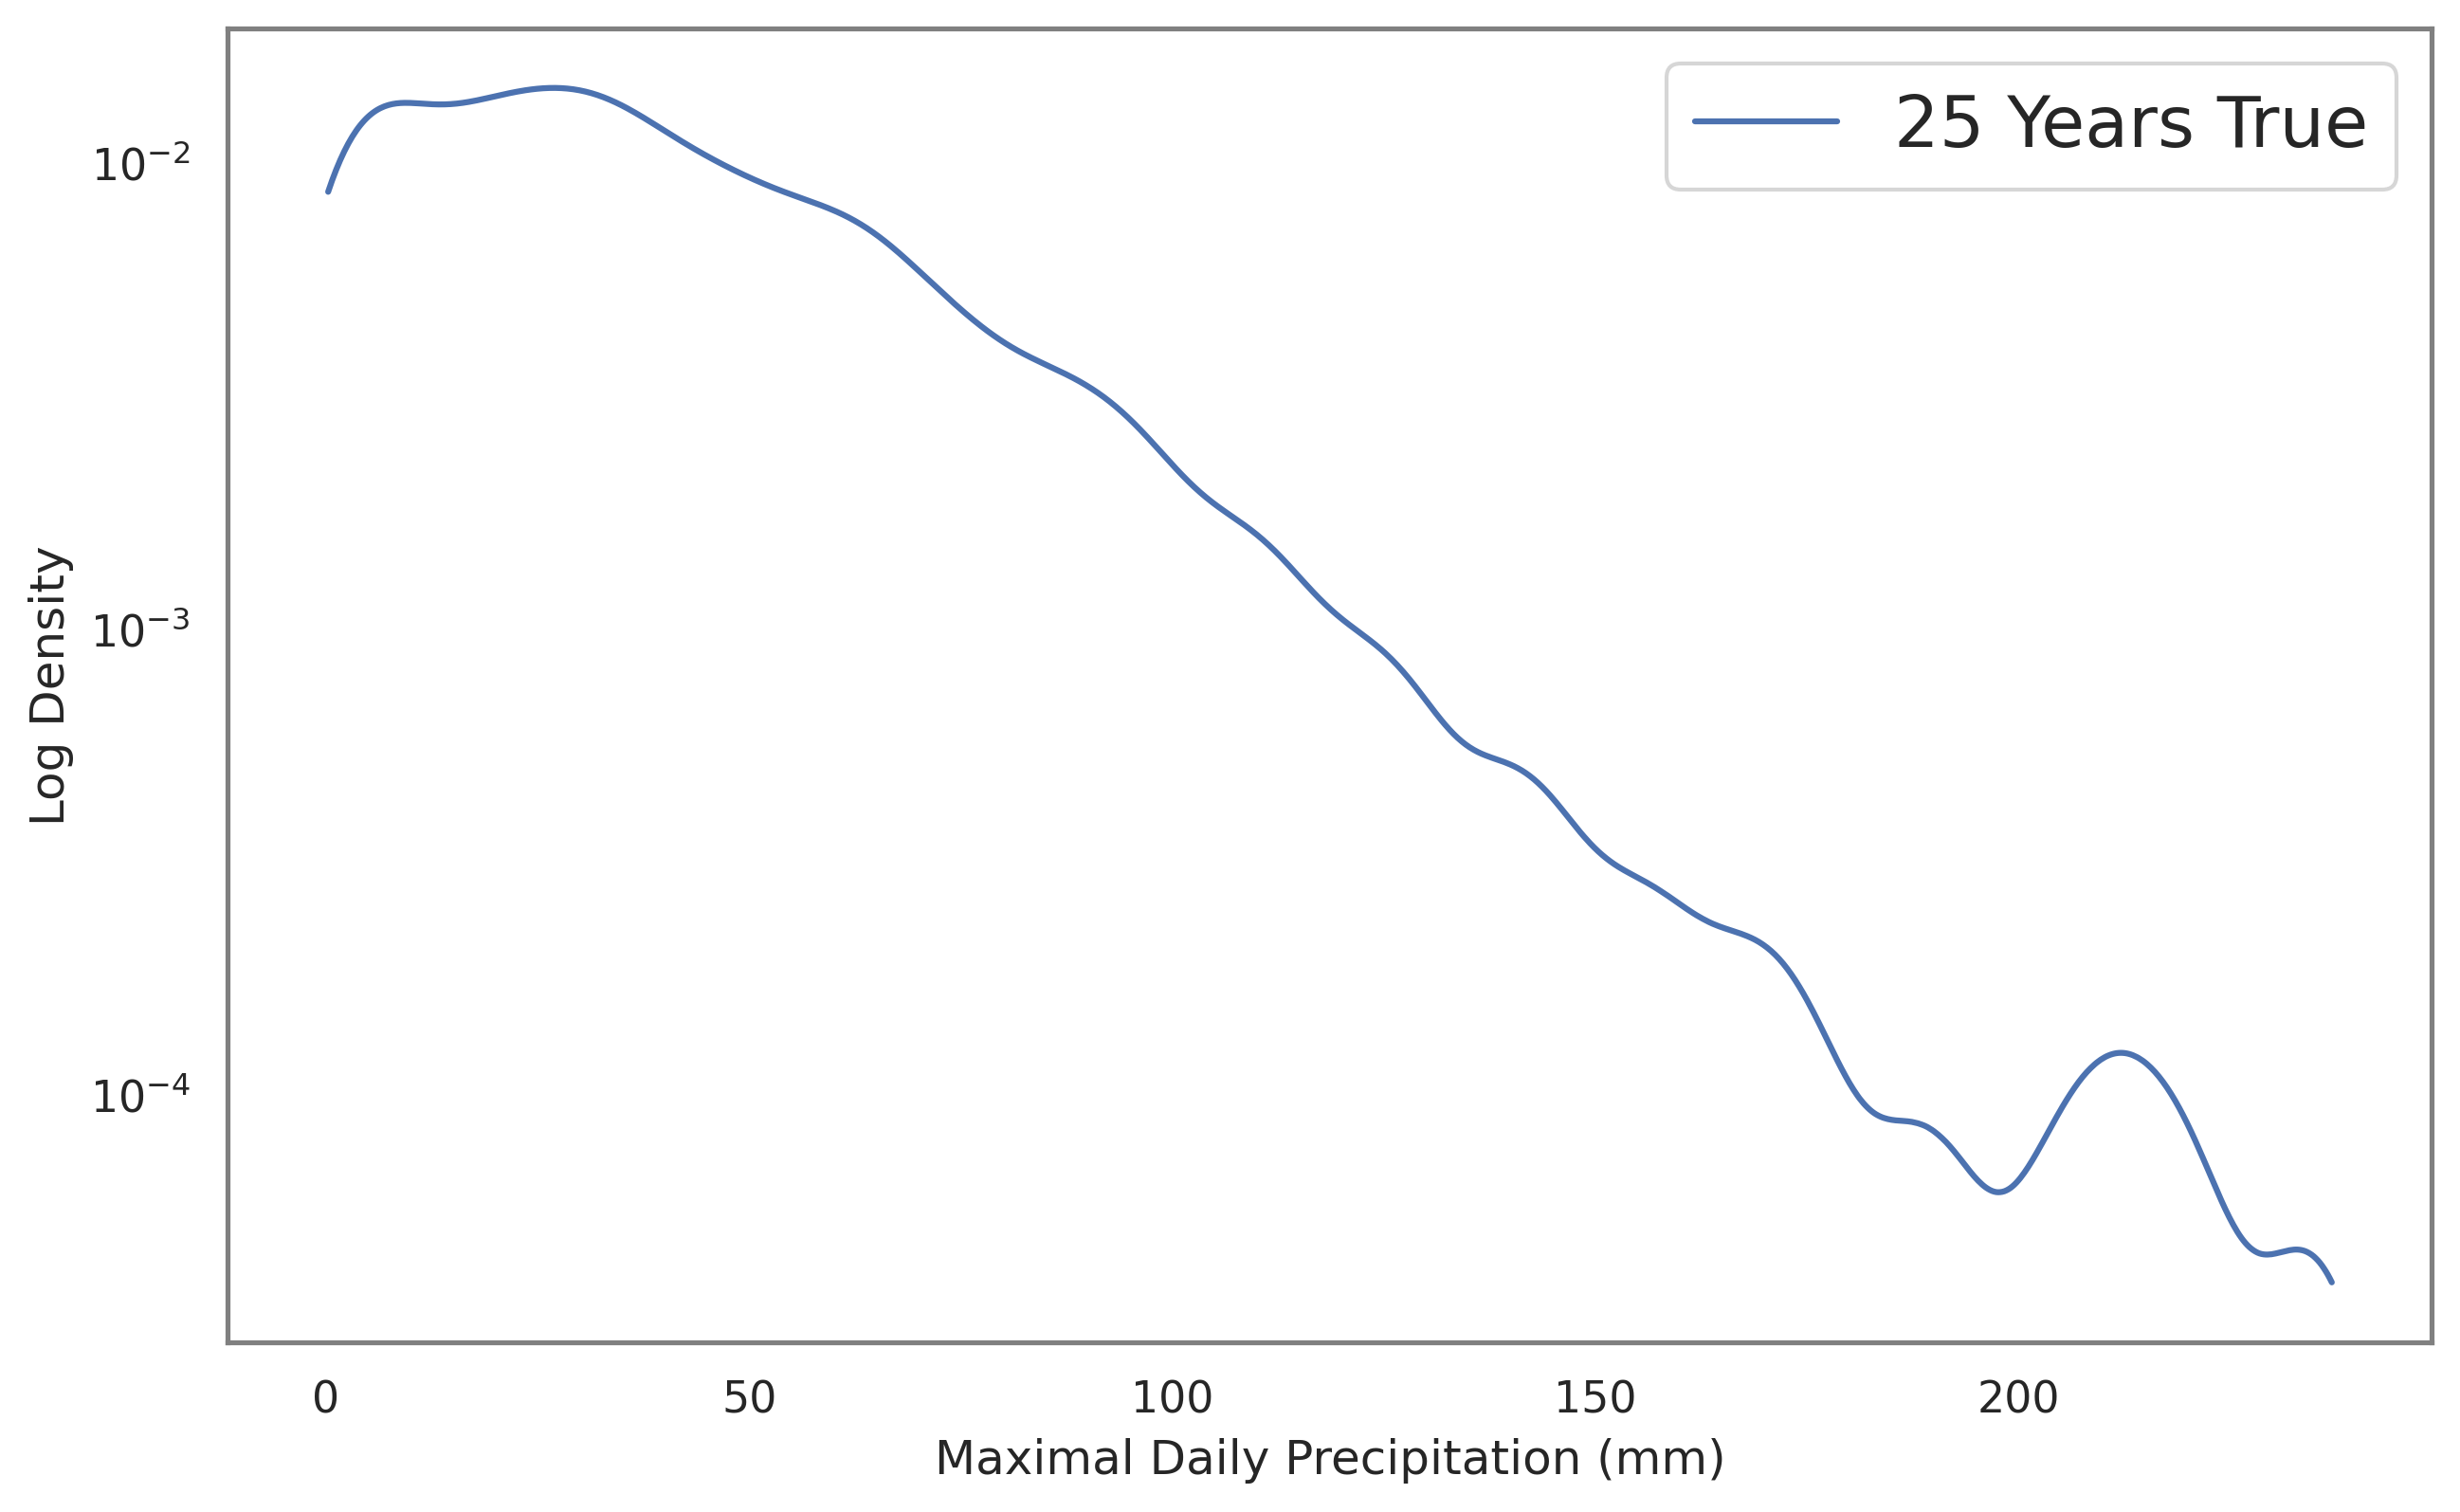

In [10]:
max_values = np.max(tp_trim_numpy, axis=(1, 2))
y_eval_tp, py_tp, _ = get_data_pdf(data=torch.tensor(max_values), data_all=torch.tensor(max_values))
# y_eval_tp_train, py_tp_train, _ = get_data_pdf(data=torch.tensor(train_max_values), data_all=torch.tensor(train_max_values))

# Plotting the two KDEs for comparison
plt.figure(figsize=(10, 6), dpi=300)

# Plot the KDE for the original data
plt.plot(y_eval_tp, py_tp, label="25 Years True")
# plt.plot(y_eval_tp_train, py_tp_train, label="5 Year True")

# Add plot labels and title
plt.xlabel("Maximal Daily Precipitation (mm)")
plt.ylabel("Log Density")
# plt.title("PDF of Regional Max Precipitation", fontsize=14)
plt.yscale('log')
plt.legend(prop={"size" : 18})

# Select Training Data

In [11]:
import torch.optim as optim
from rich.progress import Progress
from torch.utils.data import DataLoader, TensorDataset
from copy import deepcopy
import os
import gc

# Convert numpy arrays to PyTorch tensors and move to GPU
tp_trim_ds_tensor = torch.tensor(tp_trim_ds_numpy, dtype=torch.float32).unsqueeze(1).to(device)  # Add channel dimension
tp_trim_tensor = torch.tensor(tp_trim_numpy, dtype=torch.float32).unsqueeze(1).to(device)  # Full-resolution target

# Use 20% of the data (5 years) for training
num_years = 0.5
portion = num_years/25
train_size = int(portion * len(tp_trim_ds_tensor))
train_input = tp_trim_ds_tensor[:train_size]
train_target = tp_trim_tensor[:train_size]

# use full data to select the best MSE model for baseline comparison
test_input = deepcopy(tp_trim_ds_tensor)
test_target = deepcopy(tp_trim_tensor)

# move data to device
train_input = train_input.to(device)
train_target = train_target.to(device)
test_input = test_input.to(device)
test_target = test_target.to(device)

# Create DataLoader for batch processing
batch_size = 64
train_dataset = TensorDataset(train_input, train_target)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=25*batch_size, shuffle=False)

print(train_input.shape)
print(train_target.shape)
print(test_input.shape)
print(test_target.shape)

torch.Size([180, 1, 8, 16])
torch.Size([180, 1, 80, 160])
torch.Size([9044, 1, 8, 16])
torch.Size([9044, 1, 80, 160])


# Training Data v.s. Full Data PDF

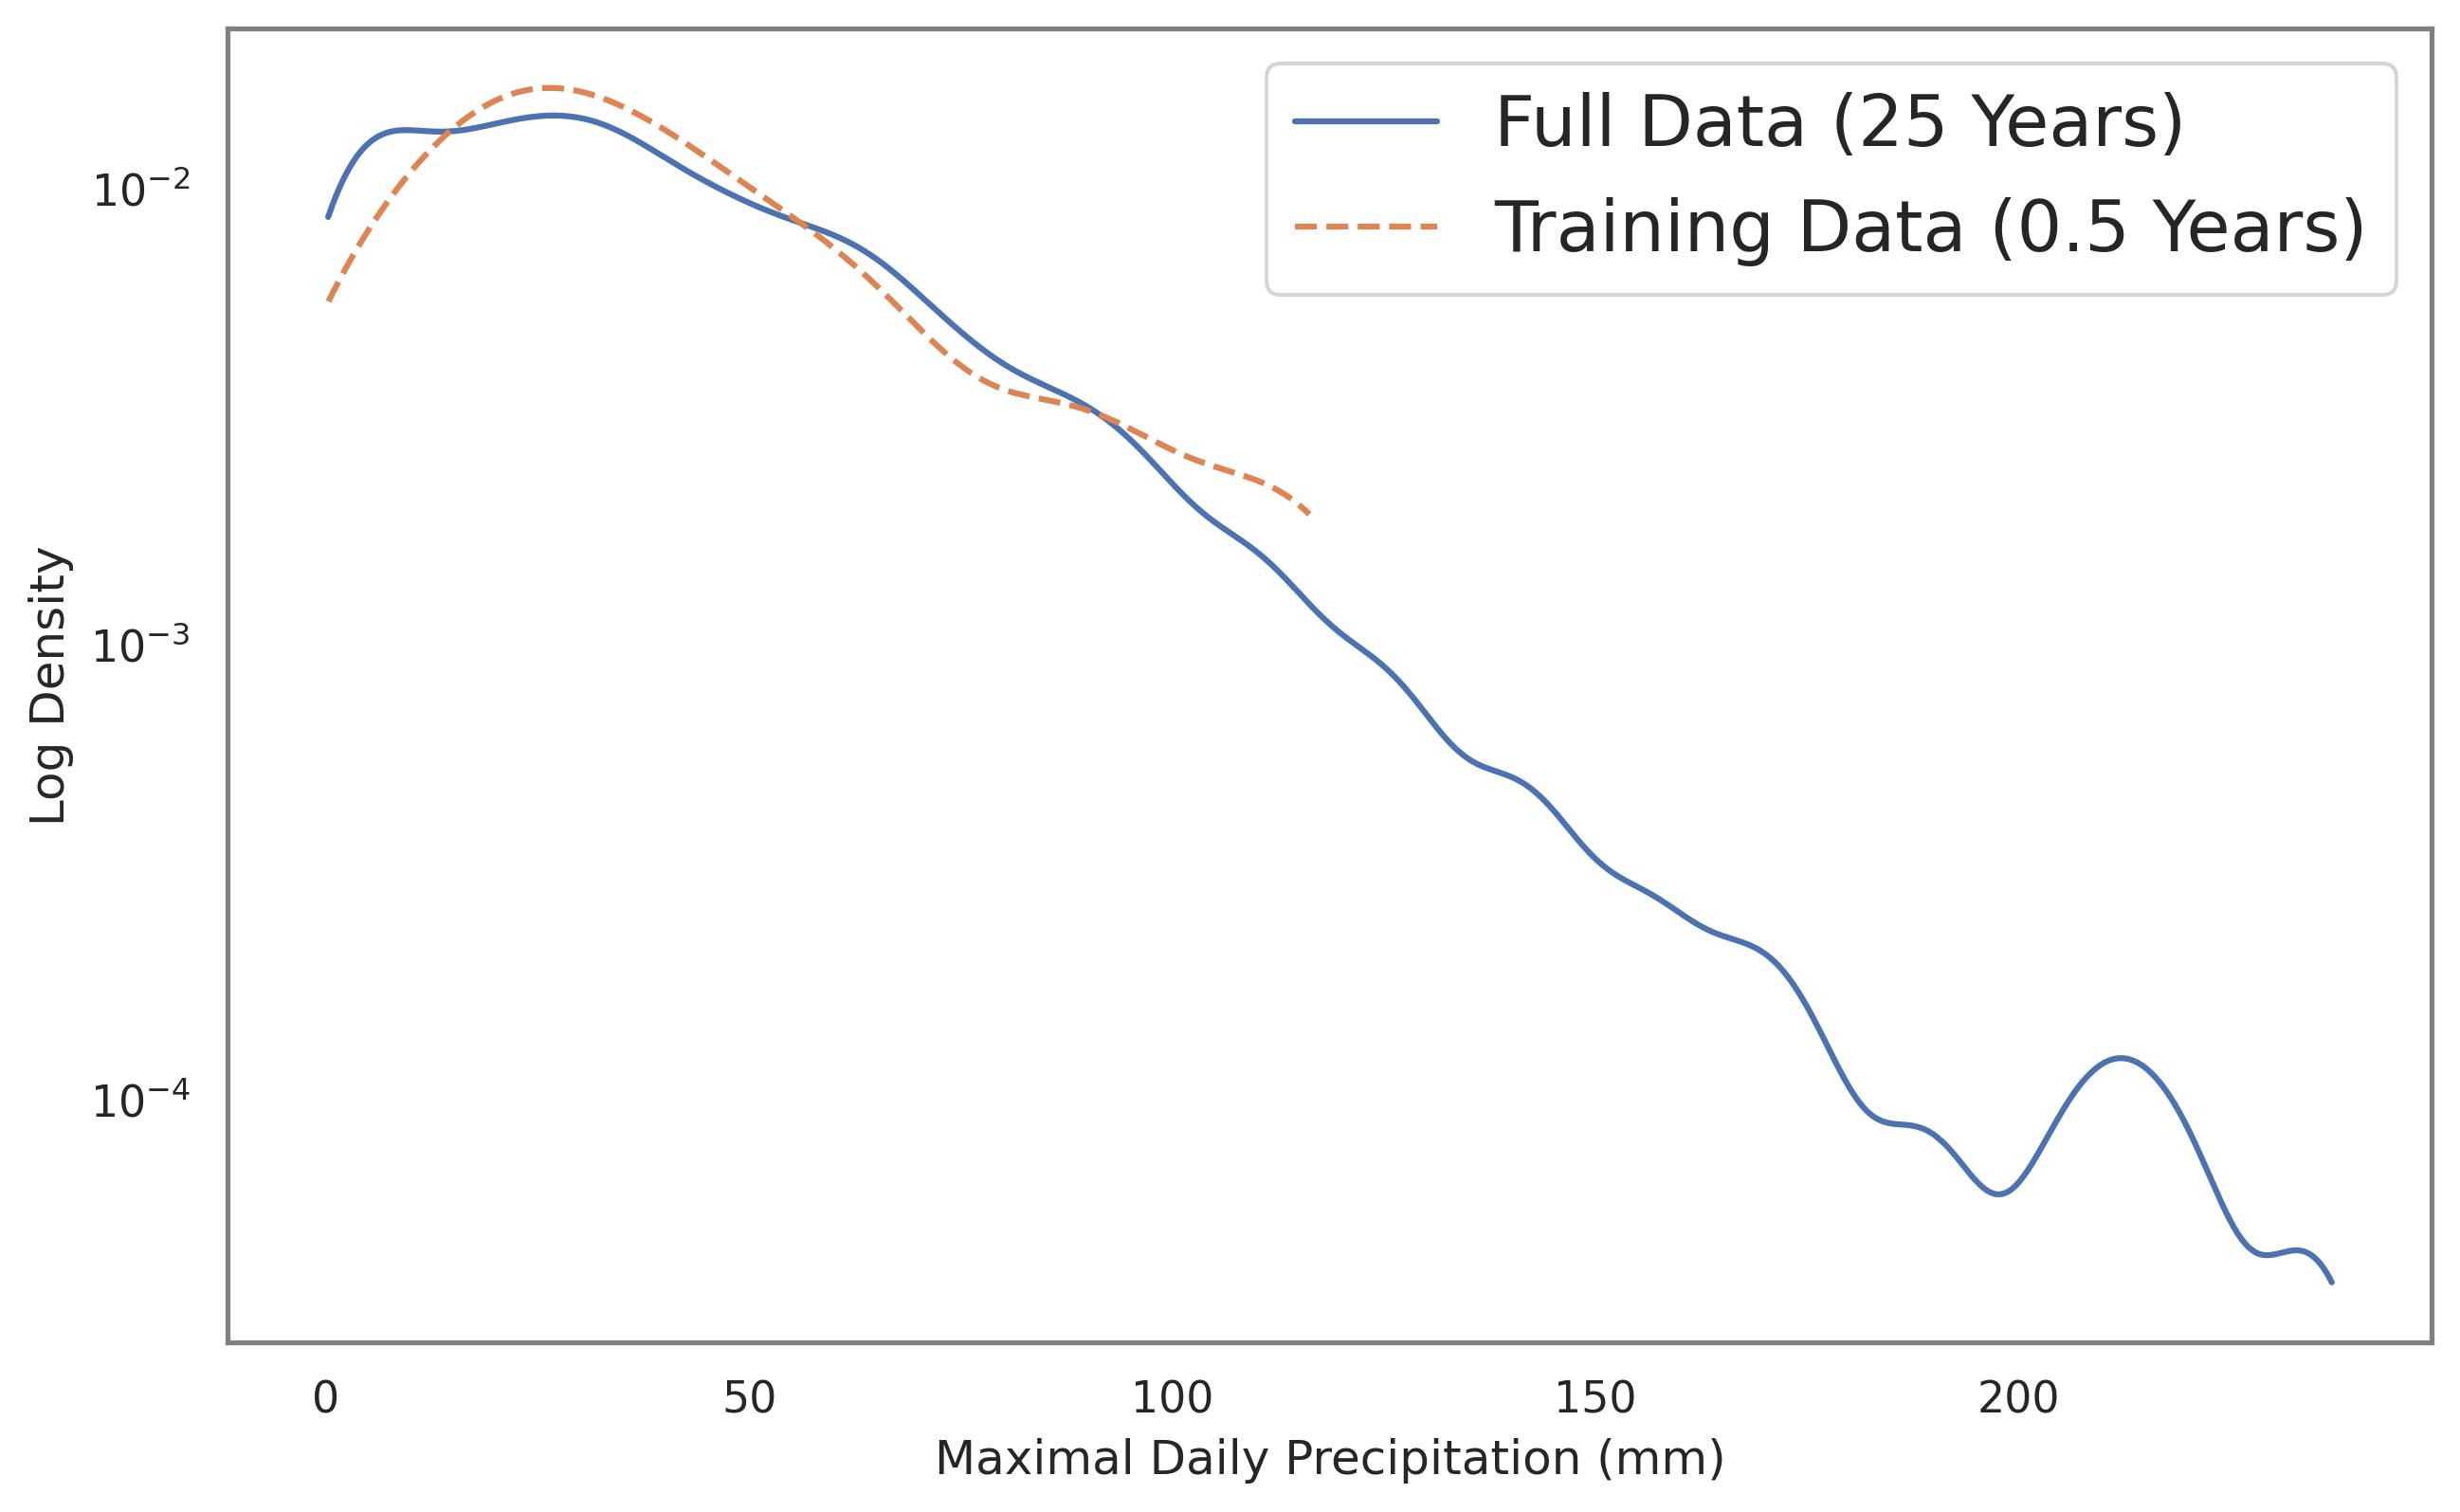

In [12]:
train_max_values = np.max(tp_trim_numpy[:train_size], axis=(1, 2))
y_eval_tp_train, py_tp_train, _ = get_data_pdf(data=torch.tensor(train_max_values), data_all=torch.tensor(train_max_values))

# Plotting the two KDEs for comparison
plt.figure(figsize=(10, 6), dpi=300)

# Plot the KDE for the original data
plt.plot(y_eval_tp, py_tp, label="Full Data (25 Years)")
plt.plot(y_eval_tp_train, py_tp_train, label=f"Training Data ({num_years} Years)", linestyle='--')

# Add plot labels and title
plt.xlabel("Maximal Daily Precipitation (mm)")
plt.ylabel("Log Density")
# plt.title("PDF of Regional Max Precipitation", fontsize=14)
plt.yscale('log')
plt.legend(prop={"size" : 18})

# Preprocess Generative Model Training Data

In [13]:
# preprocess data 
def get_hires_dgm_train(num_years):
    portion = num_years/25
    train_size = int(portion * len(tp_trim_ds_tensor))
    dgm_train = tp_trim_numpy[:train_size]
    dgm_train = np.clip(dgm_train, 1e0, None)
    dgm_train = np.log(dgm_train)
    train_mean = dgm_train.mean()
    train_std = dgm_train.std()
    dgm_train = (dgm_train - train_mean) / train_std
    inverse_transform = lambda x : np.exp(x*train_std + train_mean)
    return dgm_train, inverse_transform

def get_lores_dgm_train(num_years):
    portion = num_years/25
    train_size = int(portion * len(tp_trim_ds_tensor))
    dgm_train = tp_trim_ds_numpy[:train_size]
    dgm_train = np.clip(dgm_train, 1e0, None)
    dgm_train = np.log(dgm_train)
    train_mean = dgm_train.mean()
    train_std = dgm_train.std()
    dgm_train = (dgm_train - train_mean) / train_std
    inverse_transform = lambda x : np.exp(x*train_std + train_mean)
    return dgm_train, inverse_transform

In [14]:
def max_pairwise_distance(input_data):
    """
    Computes the maximum pairwise Euclidean distance among all images in ddpm_train
    using an iterative approach to save memory.

    Parameters:
    - ddpm_train (np.ndarray): Array of shape (9044, 8, 16)

    Returns:
    - max_distance (float): The maximum Euclidean distance found among all pairs
    """
    n_samples, height, width = input_data.shape
    data = input_data.reshape(n_samples, height * width)
    max_distance = 0.0
    
    for i in range(n_samples):
        if i % 1000 == 0 and i > 0:
            print(f"Processed {i} / {n_samples} samples...")
        # Compute distances between the i-th sample and all subsequent samples
        diffs = data[i+1:] - data[i]
        dists = np.linalg.norm(diffs, axis=1)
        if dists.size > 0:
            current_max = dists.max()
            if current_max > max_distance:
                max_distance = current_max
    
    print(f"The maximum pairwise Euclidean distance is: {max_distance}")
    return max_distance


# beta_max = max_pairwise_distance(ddpm_train)
# print(ddpm_train.shape)

# Flow Matching

In [15]:
from models import WrappedModel
from flow_matching.solver import ODESolver

def dopri5_step(v, x, t, h):
    """
    Performs one integration step using the Dormand-Prince 5th order method.
    
    Args:
        v: Velocity field function v(x, t) that returns dx/dt.
        x: Current state tensor.
        t: Current time (float).
        h: Step size (float).
    
    Returns:
        x_next: Updated state after one step.
    """
    # Compute the stages
    k1 = v(x, t)
    k2 = v(x + h*(1/5) * k1, t + h/5)
    k3 = v(x + h*(3/40 * k1 + 9/40 * k2), t + 3*h/10)
    k4 = v(x + h*(44/45 * k1 - 56/15 * k2 + 32/9 * k3), t + 4*h/5)
    k5 = v(x + h*(19372/6561 * k1 - 25360/2187 * k2 + 64448/6561 * k3 - 212/729 * k4), t + 8*h/9)
    k6 = v(x + h*(9017/3168 * k1 - 355/33 * k2 + 46732/5247 * k3 + 49/176 * k4 - 5103/18656 * k5), t + h)
    
    # Update state using the weighted combination for the 5th order solution
    x_next = x + h * (35/384 * k1 + 500/1113 * k3 + 125/192 * k4 - 2187/6784 * k5 + 11/84 * k6)
    return x_next

def dopri5_fm_sampling(model, step_size, nsamples, batch_size, image_size):
    """
    dopri5 ODE solver for flow matching.
    
    The ODE defined by the velocity field model(x, t) is integrated from t=0 to t=1.
    The initial condition is sampled from a standard Gaussian.
    
    Args:
        model: A callable velocity field function f(x, t) returning dx/dt.
        step_size: Fixed integration step size (float). For example, 0.01.
        nsamples: Total number of samples to generate (int).
        batch_size: Number of samples processed per batch (int).
        image_size: Tuple (H, W, C) defining the height, width, and number of channels.
        
    Returns:
        Tensor of shape (nsamples, C, H, W) containing the generated samples.
    """
    H, W, C = image_size  # Provided as (H, W, C)
    
    # Determine the device from the model parameters (if available) or default
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Calculate the number of integration steps from t=0 to t=1
    num_steps = int(1.0 / step_size)
    
    samples_list = []
    n_batches = nsamples // batch_size + (1 if nsamples % batch_size != 0 else 0)
    
    model.eval()
    with torch.no_grad():
        for i in range(n_batches):
            # Handle the last batch if it's smaller than batch_size
            current_batch_size = batch_size if i < n_batches - 1 else nsamples - batch_size * i
            
            # Initialize samples with a standard Gaussian
            x = torch.randn(current_batch_size, C, H, W, device=device)
            t = torch.zeros(x.shape[0], device=device)
            # Integrate from t=0 to t=1 using fixed steps
            print(f'Batch {i+1}')
            for _ in tqdm(range(num_steps)):
                x = dopri5_step(model, x, t, step_size)
                t += step_size
            samples_list.append(x)
    
    # Concatenate all batches and ensure we return exactly nsamples
    samples = torch.cat(samples_list, dim=0)
    return samples[:nsamples]

# Big Flow Matching Loop

In [20]:
from models import UNet
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from tqdm import tqdm
import os
import gc
import warnings # To avoide meshgrid warning
warnings.filterwarnings("ignore", category=UserWarning, module='torch')

# Define model parameters
image_channels = 1
n_channels = 16
ch_mults = (1, 2, 2, 4)
is_attn = (False, False, True, True)
n_blocks = 1

ONLY_SAMPLING = False

num_year_list = [25]
epoch_list = [100]
batch_size_list = [128]
step_list = [200]
for num_years, epochs, train_batch_size, nsteps in zip(num_year_list, epoch_list, batch_size_list, step_list):
    
    # checkpoint
    save_path = f"./models/fm/hires-fm-unet{n_channels}-{num_years}yr-{epochs}epoch-{train_batch_size}bsize.pth"
    print(save_path)
    # training data
    fm_train, inverse_transform = get_hires_dgm_train(num_years)
    
    if not ONLY_SAMPLING:
        # training
        # velocity field
        model = UNet(image_channels=image_channels, n_channels=n_channels,
                        ch_mults=ch_mults, is_attn=is_attn, n_blocks=n_blocks)
        model = torch.nn.DataParallel(model)#, device_ids=[3])
        model = model.to(DEVICE)

        # instantiate an affine path object
        path = AffineProbPath(scheduler=CondOTScheduler())

        # training hyperparams
        lr = 3e-4

        # training modules
        optimizer = torch.optim.Adam(model.parameters(), lr=lr) 
        cfm_loss = nn.MSELoss()

        # training data
        fm_train, inverse_transform = get_hires_dgm_train(num_years)
        fm_train = torch.tensor(fm_train)
        fm_train = fm_train.unsqueeze(1)
        dataset = TensorDataset(fm_train)
        train_loader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True, num_workers=1, pin_memory=True)

        # start training
        model.train()
        best_loss = float('inf')
        for epoch in tqdm(range(epochs)):
            cumulative_loss = 0
            for batch_idx, x_1 in enumerate(train_loader):
                optimizer.zero_grad() 

                # sample x0
                x_1 = x_1[0].to(DEVICE)
                x_0 = torch.randn_like(x_1).to(DEVICE)

                # sample time
                t = torch.rand(x_1.shape[0]).to(DEVICE) 

                # sample probability path
                path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

                # flow matching l2 loss
                loss = cfm_loss(model(path_sample.x_t,path_sample.t), path_sample.dx_t)
                cumulative_loss += loss.item()

                # optimizer step
                loss.backward() # backward
                optimizer.step() # update

            epoch_loss = cumulative_loss / (batch_idx+1)
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                torch.save(model.state_dict(), save_path)
    
    
    # sampling
    model = UNet(image_channels=image_channels, n_channels=n_channels,
            ch_mults=ch_mults, is_attn=is_attn, n_blocks=n_blocks)
    model = torch.nn.DataParallel(model)#, device_ids=[3])
    model.load_state_dict(torch.load(save_path))
    model = model.to(DEVICE)
    
    img_size = (80,160,1)
    step_size = 1/nsteps
    nsamples = 9044
    batch_size = 9044  # batch size
    sampled_images = dopri5_fm_sampling(model, 
                                        step_size, 
                                        nsamples, 
                                        batch_size, 
                                        img_size)
    sampled_images = sampled_images.squeeze().cpu().numpy()
    sampled_images = inverse_transform(sampled_images)
    save_path_samples = f"./samples/{nsamples}samples-hires-fm-{nsteps}step-unet{n_channels}-{num_years}yr-{epochs}epoch.npy"
    print(save_path_samples)
    np.save(save_path_samples, sampled_images)    

./models/fm/hires-fm-unet16-25yr-100epoch-128bsize.pth


100%|██████████| 100/100 [51:11<00:00, 30.72s/it]


Batch 1


100%|██████████| 200/200 [15:47<00:00,  4.74s/it]


./samples/9044samples-hires-fm-200step-unet16-25yr-100epoch.npy


# Training

In [ ]:
## Train Flow Matching
from models import UNet
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from tqdm import tqdm
import os
# global_seed(40)

# To avoide meshgrid warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='torch')

# Define model parameters
image_channels = 1
n_channels = 16
ch_mults = (1, 2, 2, 4)
is_attn = (False, False, True, True)
n_blocks = 1

# velocity field
model = UNet(image_channels=image_channels, n_channels=n_channels,
                ch_mults=ch_mults, is_attn=is_attn, n_blocks=n_blocks)
model = torch.nn.DataParallel(model)#, device_ids=[3])
model = model.to(DEVICE)

# instantiate an affine path object
path = AffineProbPath(scheduler=CondOTScheduler())

# training hyperparams
train_batch_size = 16
lr = 3e-4
epochs = 100
print_every = 1

# training modules
optimizer = torch.optim.Adam(model.parameters(), lr=lr) 
cfm_loss = nn.MSELoss()

# training data
num_years = 2.5
fm_train, inverse_transform = get_hires_dgm_train(num_years)
fm_train = torch.tensor(fm_train)
fm_train = fm_train.unsqueeze(1)
dataset = TensorDataset(fm_train)
train_loader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True, num_workers=1, pin_memory=True)

In [ ]:
# checkpoint
save_path = f"./models/fm/hires-fm-unet{n_channels}-{num_years}yr-{epochs}epoch.pth"
print(save_path)

# seed
# global_seed(40)

# start training
model.train()
best_loss = float('inf')
for epoch in tqdm(range(epochs)):
    cumulative_loss = 0
    for batch_idx, x_1 in enumerate(train_loader):
        optimizer.zero_grad() 

        # sample x0
        x_1 = x_1[0].to(DEVICE)
        x_0 = torch.randn_like(x_1).to(DEVICE)
    
        # sample time
        t = torch.rand(x_1.shape[0]).to(DEVICE) 
    
        # sample probability path
        path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)
    
        # flow matching l2 loss
        loss = cfm_loss(model(path_sample.x_t,path_sample.t), path_sample.dx_t)
        cumulative_loss += loss.item()
        
        # optimizer step
        loss.backward() # backward
        optimizer.step() # update
        
    epoch_loss = cumulative_loss / (batch_idx+1)
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), save_path)
        
    if (epoch) % print_every==0:
        print("\tEpoch", epoch + 1, "complete!", "\tCFM Loss: ", epoch_loss)
print("Finish!!")

# Sampling

In [16]:
from models import UNet

# Define model parameters
n_channels = 16
epochs = 100
load_path = f"./models/fm/hires-fm-unet{n_channels}-{num_years}yr-{epochs}epoch.pth"
model = UNet(image_channels=image_channels, n_channels=n_channels,
            ch_mults=ch_mults, is_attn=is_attn, n_blocks=n_blocks)
model = torch.nn.DataParallel(model, device_ids=[3])
model.load_state_dict(torch.load(load_path))
device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [17]:

# def fm_sample(wrapped_model, 
#               img_size, 
#               step_size=0.01,
#               N=5, 
#               batch_size=1,
#               method='dopri5',
#               T=None):
    
#     # Flow Matching Sampling
#     H,W,C = img_size
#     images = torch.zeros(1,C,H,W).to(wrapped_model.device)
#     if T is None:
#         T = torch.linspace(0.,1., int(1/step_size)+1).to(wrapped_model.device)
#     solver = ODESolver(velocity_model=wrapped_model)

#     nbatch = N//batch_size if N%batch_size==0 else N//batch_size + 1
#     for b in tqdm(range(nbatch)):
#         if b==nbatch-1:
#             nimage = N - batch_size*(nbatch-1)
#         else:
#             nimage = batch_size
#         x_0 = torch.randn((nimage, C,H,W), dtype=torch.float32, device=wrapped_model.device)
#         x_1 = solver.sample(time_grid=T, x_init=x_0, method=method, step_size=step_size, return_intermediates=False)
#         images = torch.cat((images, x_1), dim=0)

#     return images[1:]


# img_size = (8,16,1)
# img_size = (80,160,1)
# nspaces = 100
# step_size = 1/nspaces
# nsamples = 9044
# batch_size = 2000  # batch size
# sampled_images = dopri5_fm_sampling(model, 
#                                     step_size, 
#                                     nsamples, 
#                                     batch_size, 
#                                     img_size)

In [19]:
sampled_images = sampled_images.squeeze().cpu().numpy()
sampled_images = inverse_transform(sampled_images)

In [20]:
save_path_samples = f"./samples/{nsamples}samples-hires-fm-unet{n_channels}-{num_years}yr-{epochs}epoch.npy"
print(save_path_samples)
np.save(save_path_samples, sampled_images)

./samples/9044samples-hires-fm-unet16-2.5yr-100epoch.npy


# Diffusion Training + Sampling

In [25]:
import math
from tqdm import tqdm
import os
from models import Diffusion, UNet

# Set device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from torch.optim import Adam
import numpy as np

n_timesteps = 1000
beta_minmax=[1e-4, 1e-2]

train_batch_size = 60
lr = 3e-4
epochs = 80

seed = 1234
global_seed(seed)

img_size = (80,160,1)
# img_size = (8,16,1)

# Define model parameters
image_channels = 1
n_channels = 64
ch_mults = (1, 2, 3, 4)
is_attn = (False, False, True, True)
n_blocks = 1


## train multiple models 
num_year_list = [0.5, 2.5, 10, 17.5, 25]
epoch_list = [200, 100, 100, 50, 50]
batch_size_list = [16, 32, 128, 128, 128]
for num_years, epochs, train_batch_size in zip(num_year_list, epoch_list, batch_size_list):
    # get training data
    ddpm_train, inverse_transform = get_hires_dgm_train(num_years)
    ddpm_train = torch.tensor(ddpm_train)
    ddpm_train = ddpm_train.unsqueeze(1)
    dataset = TensorDataset(ddpm_train)
    train_loader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True, num_workers=1, pin_memory=True)
    
    # Instantiate the model
    save_path_ddpm = f"./models/ddpm/hires-ddpm-unet{n_channels}-{num_years}yr-{epochs}epoch.pth"
    model = UNet(image_channels=image_channels, n_channels=n_channels,
                ch_mults=ch_mults, is_attn=is_attn, n_blocks=n_blocks)
    model = torch.nn.DataParallel(model)
    model = model.to(device)  # Use all available GPUs
    diffusion = Diffusion(model, image_resolution=img_size, n_times=n_timesteps, 
                          beta_minmax=beta_minmax, device=DEVICE).to(DEVICE)

    optimizer = Adam(diffusion.parameters(), lr=lr)
    denoising_loss = nn.MSELoss()
    
    
    model.train()
    best_denoise_loss = float('inf')
    for epoch in tqdm(range(epochs)):
        noise_prediction_loss = 0
        for batch_idx, x in enumerate(train_loader):
            optimizer.zero_grad()

            # Ensure data is sent to the correct device
            x = x[0].to(DEVICE)
            noisy_input, epsilon, pred_epsilon = diffusion(x)
            loss = denoising_loss(pred_epsilon, epsilon)
            noise_prediction_loss += loss.item()
            loss.backward()
            optimizer.step()
            
        epoch_denoise_loss = noise_prediction_loss / batch_idx
        if epoch_denoise_loss < best_denoise_loss:
            best_denoise_loss = epoch_denoise_loss
            # torch.save(model.state_dict(), save_path_ddpm)
    
    print(f'Training Finished for {num_years} data!')
    # sampling code
    model = UNet(image_channels=image_channels, n_channels=n_channels,
                ch_mults=ch_mults, is_attn=is_attn, n_blocks=n_blocks)
    model = torch.nn.DataParallel(model)
    model.load_state_dict(torch.load(save_path_ddpm))
    diffusion = Diffusion(model, image_resolution=img_size, n_times=n_timesteps, 
                          beta_minmax=beta_minmax, device=DEVICE).to(DEVICE)
    
    nsamples = 9000
    num_steps = 50
    batch_size = 4500
    with torch.no_grad():
        sampled_images = diffusion.sample(N=nsamples,num_steps=num_steps, batch_size=batch_size)
    print(f'Sampling Finished for {num_years} data!')
    
    sampled_images = sampled_images.squeeze().cpu().numpy()
    sampled_images = inverse_transform(sampled_images)
    save_path_samples = f"./samples/{nsamples}samples-hires-ddpm-unet{n_channels}-{num_years}yr-{epochs}epoch.npy"
    np.save(save_path_samples, sampled_images)
    
# # Single model training
# # Instantiate the model
# model = UNet(image_channels=image_channels, n_channels=n_channels,
#             ch_mults=ch_mults, is_attn=is_attn, n_blocks=n_blocks)

# diffusion = Diffusion(model, image_resolution=img_size, n_times=n_timesteps, 
#                       beta_minmax=beta_minmax, device=DEVICE).to(DEVICE)

# optimizer = Adam(diffusion.parameters(), lr=lr)
# denoising_loss = nn.MSELoss()
# ddpm_train = torch.tensor(ddpm_train)
# ddpm_train = ddpm_train.unsqueeze(1)
# dataset = TensorDataset(ddpm_train)
# train_loader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True, num_workers=1, pin_memory=True)
# model = torch.nn.DataParallel(model)
# model = model.to(device)  # Use all available GPUs
# print(model)

  0%|          | 0/200 [00:00<?, ?it/s]

torch.Size([16, 1, 80, 160])


AssertionError: 

In [ ]:
model.train()
for epoch in tqdm(range(epochs)):
    noise_prediction_loss = 0
    for batch_idx, x in enumerate(train_loader):
        optimizer.zero_grad()

        # Ensure data is sent to the correct device
        x = x[0].to(DEVICE)
        noisy_input, epsilon, pred_epsilon = diffusion(x)
        loss = denoising_loss(pred_epsilon, epsilon)
        noise_prediction_loss += loss.item()
        loss.backward()
        optimizer.step()

    if (epoch) % 1==0:
        print("\tEpoch", epoch + 1, "complete!", "\tDenoising Loss: ", noise_prediction_loss / batch_idx)
print("Finish!!")

In [34]:
save_path_ddpm = f"./models/ddpm/hires-ddpm-unet{n_channels}-{num_years}yr-{epochs}epoch.pth"
torch.save(model.state_dict(), save_path_ddpm)
print(save_path_ddpm)

./models/ddpm/hires-ddpm-unet32-25yr-80epoch.pth


In [35]:
# load trained model
which_model = 'hires'
if which_model == 'hires':
    num_years = 25
elif which_model == 'lores':
    num_years = 25
else:
    raise ValueError("Model is not available!")
    
n_channels = 32
epochs = 80

# Instantiate the model
load_path_ddpm = f"./models/ddpm/{which_model}-ddpm-unet{n_channels}-{num_years}yr-{epochs}epoch.pth"
print(load_path_ddpm)
model = UNet(image_channels=image_channels, n_channels=n_channels,
            ch_mults=ch_mults, is_attn=is_attn, n_blocks=n_blocks)
model = torch.nn.DataParallel(model)
model.load_state_dict(torch.load(load_path_ddpm))

diffusion = Diffusion(model, image_resolution=img_size, n_times=n_timesteps, 
                      beta_minmax=beta_minmax, device=DEVICE).to(DEVICE)

./models/ddpm/hires-ddpm-unet32-25yr-80epoch.pth


In [48]:
# %%time
# sample
nsamples = 9000
num_steps = 50
batch_size = 4500
with torch.no_grad():
    sampled_images = diffusion.sample(N=nsamples,num_steps=num_steps, batch_size=batch_size)
# sampled_images = sampled_images.squeeze().clamp(min=0.0).cpu().numpy()
# sampled_images = sampled_images * (ddpm_train_max - ddpm_train_min) + ddpm_train_min
print(sampled_images.shape)
print(sampled_images[0].max())

100%|██████████| 1000/1000 [39:28<00:00,  2.37s/it]


torch.Size([9000, 1, 80, 160])
tensor(0.8190, device='cuda:0')


In [49]:
sampled_images = sampled_images.squeeze().cpu().numpy()
# sampled_images = sampled_images.clip(min=0.)
sampled_images = inverse_transform(sampled_images)
# print(sampled_images.shape)
# print(sampled_images.min(), sampled_images.max())
save_path_samples = f"./samples/{nsamples}samples-{which_model}-ddpm-unet{n_channels}-{num_years}yr-{epochs}epoch.npy"
# print(save_path_samples)
np.save(save_path_samples, sampled_images)

# Load DGM Samples

In [26]:
which_dgm = 'fm'
nsamples = 9044
epochs = 80
n_channels = 16
load_path_lores_samples = f"./samples/{nsamples}samples-lores-{which_dgm}-unet{n_channels}-25yr-{epochs}epoch.npy"
lores_samples = np.load(load_path_lores_samples)
# lores_samples = sampled_images
nsamples = 9044
n_channels=16
num_years = 25
epochs = 80
load_path_hires_samples = f"./samples/{nsamples}samples-hires-{which_dgm}-unet{n_channels}-{num_years}yr-{epochs}epoch.npy"
# hires_samples = np.load(load_path_hires_samples)
hires_samples = sampled_images
print(load_path_lores_samples)
print(load_path_hires_samples)


./samples/9044samples-lores-fm-unet16-25yr-80epoch.npy
./samples/9044samples-hires-fm-unet16-25yr-80epoch.npy


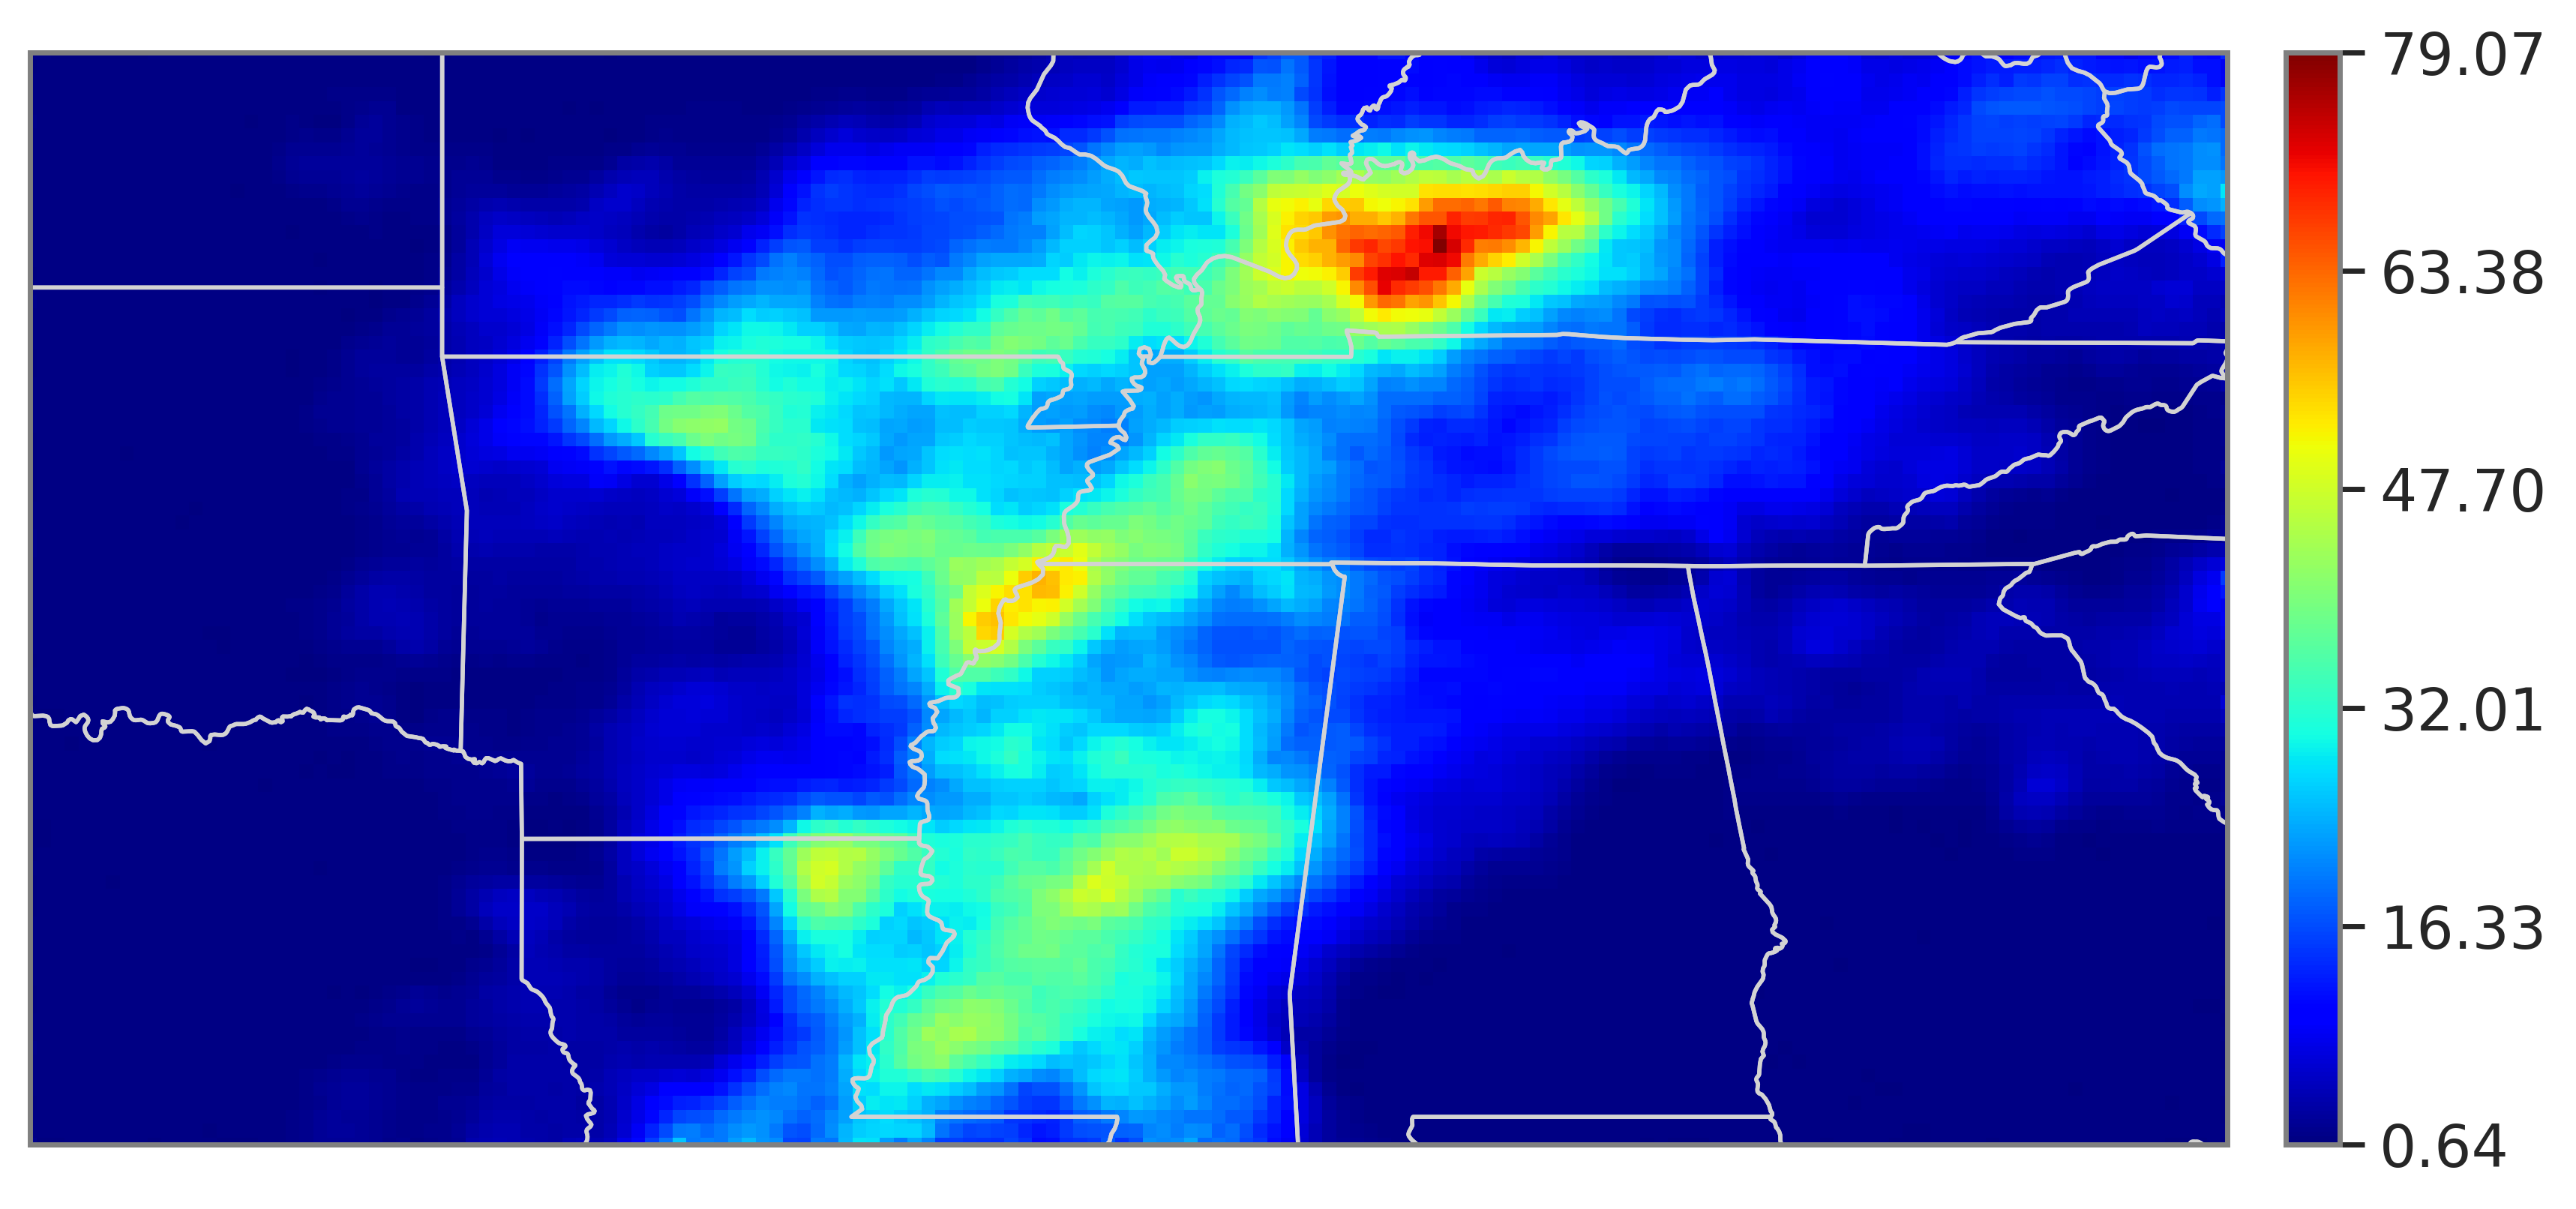

In [31]:
fig,axes = plot_nfields(hires_samples[600], longitudes=tp.longitude.values, latitudes=tp.latitude.values)

# Load All DDPM Samples

In [ ]:
load_path_hires_samples_0p5 = f"./samples/9000samples-hires-ddpm-unet16-0.5yr-50epoch.npy"
load_path_hires_samples_2p5 = f"./samples/9000samples-hires-ddpm-unet32-2.5yr-600epoch.npy"
load_path_hires_samples_10 = f"./samples/9000samples-hires-ddpm-unet32-10yr-200epoch.npy"
load_path_hires_samples_17p5 = f"./samples/9000samples-hires-ddpm-unet32-17.5yr-100epoch.npy"
load_path_hires_samples_25 = f"./samples/9000samples-hires-ddpm-unet32-25yr-80epoch.npy"
hires_samples_0p5 = np.load(load_path_hires_samples_0p5)
hires_samples_2p5 = np.load(load_path_hires_samples_2p5)
hires_samples_10 = np.load(load_path_hires_samples_10)
hires_samples_17p5 = np.load(load_path_hires_samples_17p5)
hires_samples_25 = np.load(load_path_hires_samples_25)


# $\eta$ Testing Function

In [33]:
def test_model_eta(model, TestLoader, 
                   w1_loss, w1_input, w1_truemax, w1_max_pos, 
                   device=None):
    """
    run model on TestLoader and report the MSE loss and the W1 loss
    
    return:
        - full_output: squeezed numpy array with dimension (N,...)
        - test_loss_mse: mean squared error on TestLoader
    
    """
    if not device:
        device = next(model.parameters()).device
    model.to(device)
    model.eval()
    _, sample_target = next(iter(TestLoader))
    full_output = torch.zeros_like(test_target[0]).cpu()
    mse_loss = nn.MSELoss()
    running_test_mse_loss = 0.0
    
    with torch.no_grad():
        for _, (test_in, test_tar) in enumerate(test_loader):
            test_in, test_tar = test_in.to(device), test_tar.to(device)  
            test_output = model(test_in).detach()
            loss = mse_loss(test_output, test_tar)
            running_test_mse_loss += loss.item()
            full_output = torch.cat((full_output,test_output.squeeze().cpu()),dim=0)
    test_mse_loss = running_test_mse_loss/len(test_loader)
    
    # when testing, should record the true tail values
    num_w1_days = len(w1_truemax)
    full_output = full_output[1:].numpy()
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    sorted_max_values_output = max_values_output[sorted_indices_output]
    w1_max_test = torch.tensor(sorted_max_values_output[-num_w1_days:])
    w1_max_test = w1_max_test.to(w1_truemax.device)
    
#     w1_output_test = model(w1_input).squeeze()
#     w1_max_test = w1_output_test[tuple(w1_max_pos)]
    w1_loss_test = w1_loss(w1_max_test, w1_truemax).item()
    
    return full_output, test_mse_loss, w1_loss_test

def get_max_indices_vals(full_output : np.ndarray, num_w1_days):
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    sorted_max_values_output = max_values_output[sorted_indices_output]
    max_indices = sorted_indices_output[-num_w1_days:]
    max_vals = torch.tensor(sorted_max_values_output[-num_w1_days:])
    return max_indices, max_vals

# Load $\eta$-Map

In [34]:
from models import SRCNN
num_years = 0.5
ds_fact = 10
w1_tail_thresh = 150
omega = 30
load_dir = "./models/precip-srcnn/"
model_eta_filename = f"srcnn-eta-{num_years}yr-{ds_fact}ds-{w1_tail_thresh}tail-{omega}omega.pth"
model_eta = SRCNN(hidden_dim=64, num_blocks=3, scale_factor=ds_fact)
load_path_eta = os.path.join(load_dir, model_eta_filename)
model_eta = nn.DataParallel(model_eta, device_ids=[3])
model_eta.load_state_dict(torch.load(load_path_eta))
model_eta.to(device)
print()

# Run $\eta$ on Generated Low-Res Samples

In [35]:
batch_size = 256
test_dataset = TensorDataset(torch.tensor(lores_samples).unsqueeze(1), torch.tensor(hires_samples).unsqueeze(1))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

w1_loss = lambda x,y: torch.abs(x-y).mean()
w1_truemax = torch.tensor([1.])
full_output_eta, _, _ = test_model_eta(
    model_eta,
    test_loader,
    w1_loss,
    None,
    w1_truemax,
    None,
    device=device
)


3


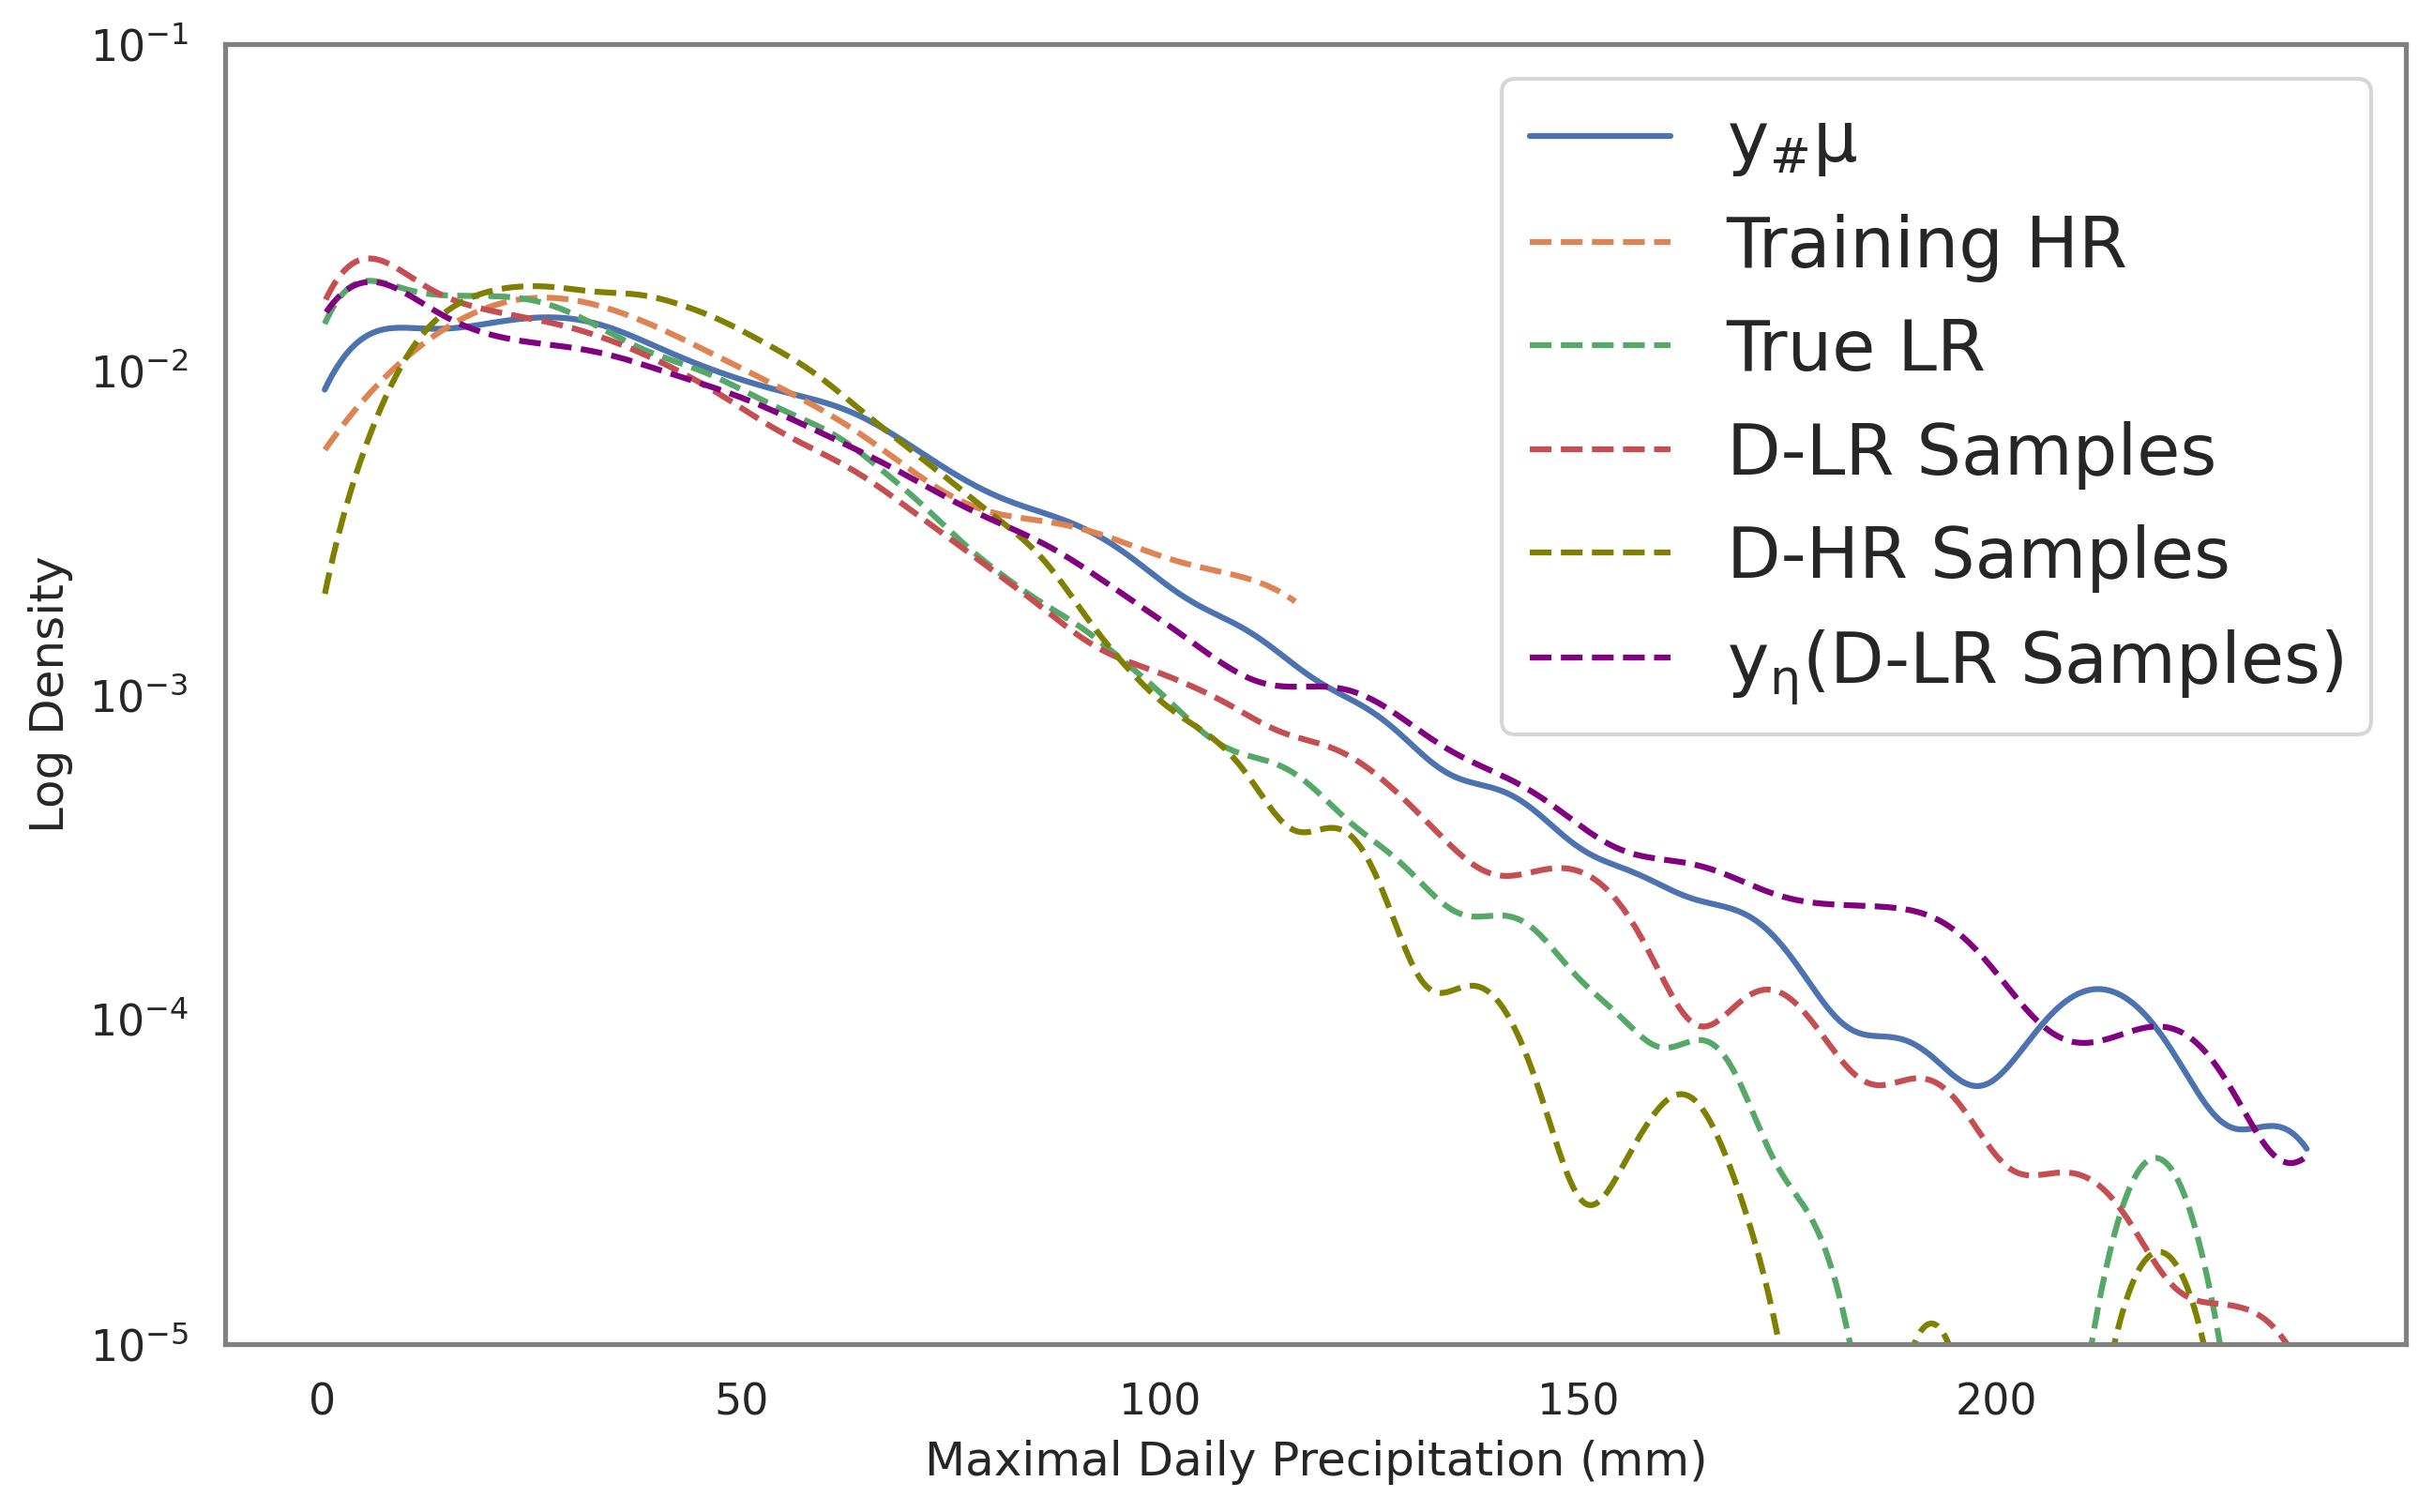

In [36]:
# diagonose ddpm sample stats
max_values_hires = np.max(hires_samples, axis=(1,2))
max_values_eta_lores = np.max(full_output_eta, axis=(1,2))
max_values_ds = np.max(tp_trim_ds_numpy, axis=(1,2))
max_values_lores = np.max(lores_samples, axis=(1,2))
print(len(max_values_hires[max_values_hires > 240]))
# max_values_hires = max_values_hires[max_values_hires < 240]
# max_values_eta_lores = max_values_eta_lores[max_values_eta_lores < 240]
# max_values_lores = max_values_lores[max_values_lores < 240]

y_eval_tp_hires, py_tp_hires, _ = get_data_pdf(data=torch.tensor(max_values_hires), data_all=torch.tensor(max_values))
y_eval_tp_ds, py_tp_ds, _ = get_data_pdf(data=torch.tensor(max_values_ds), data_all=torch.tensor(max_values))
y_eval_tp_lores, py_tp_lores, _ = get_data_pdf(data=torch.tensor(max_values_lores), data_all=torch.tensor(max_values))
y_eval_tp_eta_lores, py_tp_eta_lores, _ = get_data_pdf(data=torch.tensor(max_values_eta_lores), data_all=torch.tensor(max_values))
# Plotting the two KDEs for comparison
plt.figure(figsize=(10, 6), dpi=300)

# Plot the KDE for the original data
plt.plot(y_eval_tp, py_tp, label=r"$y_\#\mu$")
plt.plot(y_eval_tp_train, py_tp_train, label=f"Training HR", linestyle='--')
plt.plot(y_eval_tp_ds, py_tp_ds, label=r"True LR", linestyle='--')
plt.plot(y_eval_tp_lores, py_tp_lores, label=r"D-LR Samples", linestyle='--')
plt.plot(y_eval_tp_hires, py_tp_hires, label=r"D-HR Samples", linestyle='--', color='olive')
plt.plot(y_eval_tp_eta_lores, py_tp_eta_lores, label=r"$y_{\eta}$(D-LR Samples)", linestyle='--', color='purple')

# Add plot labels and title
plt.xlabel("Maximal Daily Precipitation (mm)")
plt.ylabel("Log Density")
# plt.title("PDF of Regional Max Precipitation", fontsize=14)
plt.yscale('log')
plt.ylim(1e-5,1e-1)
plt.legend(prop={"size" : 18})

In [ ]:
hires_sample_max_values_0p5 = np.max(hires_samples_0p5, axis=(1,2))
hires_sample_max_values_2p5 = np.max(hires_samples_2p5, axis=(1,2))
hires_sample_max_values_10 = np.max(hires_samples_10, axis=(1,2))
hires_sample_max_values_17p5 = np.max(hires_samples_17p5, axis=(1,2))
hires_sample_max_values_25 = np.max(hires_samples_25, axis=(1,2))

y_eval_tp_hires_sample_0p5, py_tp_hires_sample_0p5, _ = get_data_pdf(data=torch.tensor(hires_sample_max_values_0p5), data_all=torch.tensor(max_values))
y_eval_tp_hires_sample_2p5, py_tp_hires_sample_2p5, _ = get_data_pdf(data=torch.tensor(hires_sample_max_values_2p5), data_all=torch.tensor(max_values))
y_eval_tp_hires_sample_10, py_tp_hires_sample_10, _ = get_data_pdf(data=torch.tensor(hires_sample_max_values_10), data_all=torch.tensor(max_values))
y_eval_tp_hires_sample_17p5, py_tp_hires_sample_17p5, _ = get_data_pdf(data=torch.tensor(hires_sample_max_values_17p5), data_all=torch.tensor(max_values))
y_eval_tp_hires_sample_25, py_tp_hires_sample_25, _ = get_data_pdf(data=torch.tensor(hires_sample_max_values_25), data_all=torch.tensor(max_values))


In [44]:
def get_max_indices_values(full_output : np.ndarray, num_w1_days):
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    sorted_max_values_output = max_values_output[sorted_indices_output]
    max_value_indices = sorted_indices_output[-num_w1_days:]
    max_values = torch.tensor(sorted_max_values_output[-num_w1_days:])
    return max_value_indices, max_values

ndays = 100
max_value_indices_eta, max_values_eta = get_max_indices_values(full_output_eta, ndays)
ntrunc = len(max_values_eta[max_values_eta > 240])
print(max_value_indices_eta[:ndays - ntrunc])

[2455  278 3101 8351 5740 1757 3218 6825 3303 2817 6522 2303  453 6806
 6747 6717 4347 3702 2098 3454 7223 4126 1641 5874 2321  347 7793 3412
 3735 2851 1069   73 6032 6829 4017  940 6008   51 8653 4900 4479 3516
 2242 6568 8740 7646 4794 5820 3933 3939 3789 2173  104  375 7289 7400
 4001 2900 6542 2021  529 6752 1643 6388 4072 8892 4389  271  653 1933
 3729 1837 6231 5783 8145 4931   70 1229]


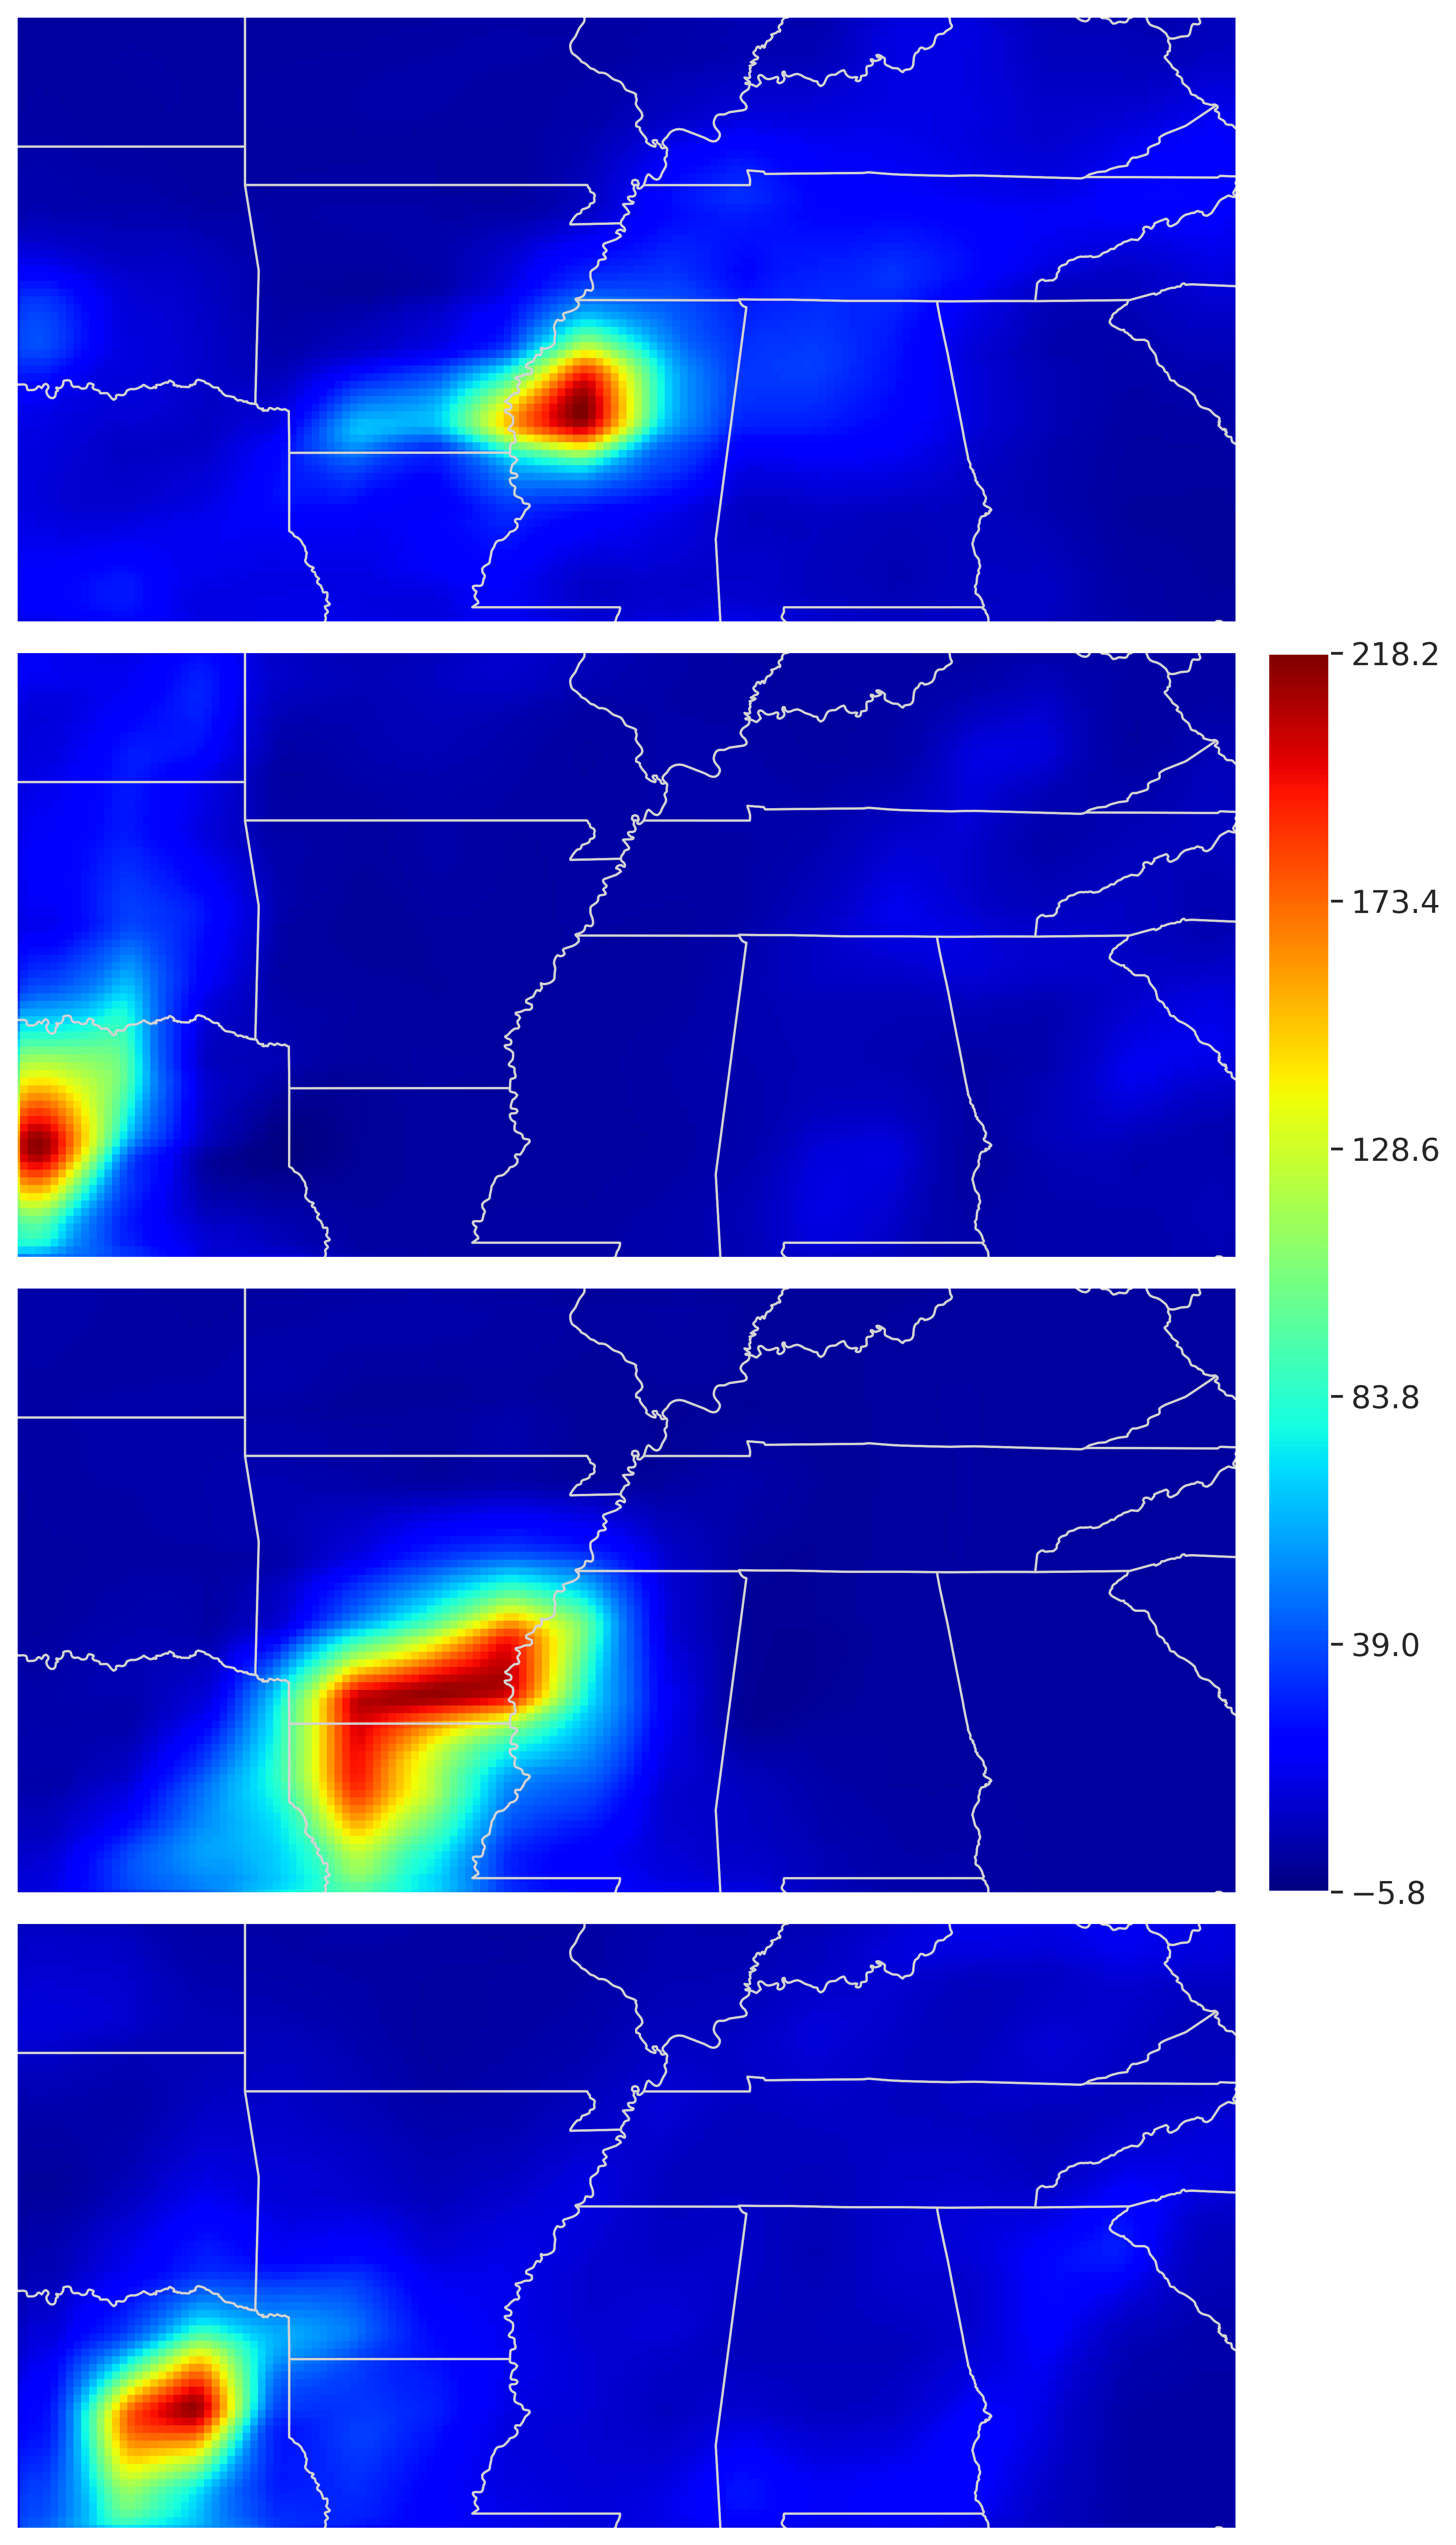

In [52]:
pic_idx = 3
fig,axes = plot_nfields(full_output_eta[max_value_indices_eta[-4*pic_idx-1-ntrunc]],
                        full_output_eta[max_value_indices_eta[-4*pic_idx-2-ntrunc]],
                        full_output_eta[max_value_indices_eta[-4*pic_idx-3-ntrunc]], 
                        full_output_eta[max_value_indices_eta[-4*pic_idx-4-ntrunc]],
                        longitudes=tp.longitude.values, latitudes=tp.latitude.values)

